# Метод фон Цейпеля

**Метод фон Цейпеля** - классический асимптотический метод теории возмущений, предназначенный для интегрирования канонических систем уравнений Гамильтона [von Zeipel, 1916]. Его цель заключается в последовательном исключении циклических (быстрых) угловых переменных из функции Гамильтона (гамильтониана) с помощью канонических преобразований. Данные преобразования задаются производящей функцией смешанного типа, зависящей от старых координат и новых импульсов.

Классическим базисом для построения асимптотических рядов фон Цейпеля служит фазовое (пространство) в переменных «действие-угол» $(I, \theta)$, в котором невозмущенный гамильтониан зависит исключительно от импульсов действия. Ниже рассмотрены математическая структура и алгоритм метода на примере одномерного слабонелинейного ангармонического осциллятора.

---

### 1. Постановка задачи

В качестве исходной модели исследуется гамильтониан одномерного линейного осциллятора с малой кубической ангармонической поправкой к потенциальной энергии:
$$H(q, p) = \frac{p^2 + q^2}{2} + \varepsilon q^3, \tag{1}$$
где $\varepsilon \ll 1$ - малый параметр возмущения.

Переход к каноническим переменным **«действие-угол»** $(I, \theta)$ для невозмущенной части системы осуществляется с помощью стандартного симплектического преобразования:
$$q = \sqrt{2I} \cos\theta, \quad p = -\sqrt{2I} \sin\theta.$$

После подстановки данных выражений в исходный гамильтониан (1) система принимает вид:
$$H(I, \theta) = I + \varepsilon (2I)^{3/2} \cos^3\theta. \tag{2}$$

На основании тригонометрического тождества $\cos^3\theta = \frac{3}{4}\cos\theta + \frac{1}{4}\cos(3\theta)$ возмущенная часть гамильтониана представляется в виде summ (суммы) спектральных гармоник:
$$H(I, \theta) = I + \varepsilon (2I)^{3/2} \left( \frac{3}{4}\cos\theta + \frac{1}{4}\cos(3\theta) \right). \tag{3}$$

Переменная $\theta$ является быстрой фазой, совершающей полный оборот за период колебания системы. Целью алгоритма является построение канонического преобразования к новым переменным $(\bar{I}, \bar{\theta})$, в которых преобразованный гамильтониан не зависит от фазы $\bar{\theta}$. Данный подход позволяет определить новое действие $\bar{I}$, служащее интегралом движения усредненной системы в первом приближении по малому параметру $\varepsilon$.


### 💡 Физический смысл переменных «действие-угол»

В классической механике колебательные движения описываются через каноническую координату $q$ и каноническую переменную импульса $p$. На фазовой плоскости траектория невозмущенного гармонического осциллятора представляет собой эллипс (в данных безразмерных переменных - окружность), задаваемый законом сохранения энергии:
$$ \frac{p^2}{2} + \frac{q^2}{2} = E. $$

Переход к переменным **«действие-угол» $(I, \theta)$** — каноническое преобразование, которое нормализует геометрию фазового пространства, связывая декартовы координаты с полярными на фазовой плоскости через радиус $R = \sqrt{2I}$:
$$ q = \sqrt{2I}\cos\theta, \quad p = -\sqrt{2I}\sin\theta. $$

* **Переменная угла ($\theta$)** определяет фазу колебаний и текущее угловое положение системы на фазовой траектории в диапазоне от $0$ до $2\pi$;
* **Переменная действия ($I$)** представляет собой канонический импульс, определяющий величину площади фазового портрета, ограниченного замкнутой траекторией:
  $$I = \frac{1}{2\pi} \oint p \, dq = \frac{E}{\omega_0}.$$
  *(Для рассматриваемой системы (1) собственная частота линейных колебаний $\omega_0 = 1$, откуда $I = E$).*

Преимущество данного базиса заключается в том, что в невозмущенной автономной системе уравнения Гамильтона принимают полностью интегрируемый линейный вид [Уиттекер, 1937]:
$$ \dot{I} = -\frac{\partial H_0}{\partial \theta} = 0 \implies I = \text{const} \quad (\text{инвариант площади фазовой траектории}); $$
$$ \dot{\theta} = \frac{\partial H_0}{\partial I} = 1 \implies \theta = t + \theta_0 \quad (\text{фаза эволюционирует с постоянной единичной скоростью}). $$

Любой асимптотический метод предназначен для построения в возмущенной нелинейной системе такого нового действия $\bar{I}$, которое является строгим интегралом движения ($\dot{\bar{I}} = 0$), в то время как новый угол $\bar{\theta}$ изменяется равномерно, но с модифицированной нелинейной частотой: $\dot{\bar{\theta}} = \bar{\omega}(\bar{I})$.


### 2. Структура канонического преобразования фон Цейпеля

Для перехода от старых переменных $(I, \theta)$ к новым усредненным переменным $(\bar{I}, \bar{\theta})$ строится близкое к тождественному каноническое преобразование второго типа. Данное преобразование задается производящей функцией смешанного типа $S(\theta, \bar{I})$, зависящей от старых угловых координат и новых импульсов действия:
$$S(\theta, \bar{I}) = \theta\bar{I} + \varepsilon S_1(\theta, \bar{I}) + O(\varepsilon^2). \tag{4}$$

Первое слагаемое $\theta\bar{I}$ порождает тождественное преобразование, а функция первого порядка $S_1(\theta, \bar{I})$ описывает периодические высокочастотные колебания системы.

В рамках канонического формализма связь между исходными и новыми переменными определяется дифференцированием производящей функции (4) [Голдстейн, 1975]:
$$I = \frac{\partial S}{\partial \theta} = \bar{I} + \varepsilon \frac{\partial S_1(\theta, \bar{I})}{\partial \theta},$$
$$\bar{\theta} = \frac{\partial S}{\partial \bar{I}} = \theta + \varepsilon \frac{\partial S_1(\theta, \bar{I})}{\partial \bar{I}}. \tag{5}$$

Новый преобразованный гамильтониан $\bar{H}(\bar{I})$ по условию метода фон Цейпеля должен быть инвариантен относительно быстрой фазы $\theta$ и зависеть исключительно от нового импульса действия $\bar{I}$. Разложение преобразованного гамильтониана в асимптотический ряд по степеням малого параметра имеет вид:
$$\bar{H}(\bar{I}) = \bar{H}_0(\bar{I}) + \varepsilon \bar{H}_1(\bar{I}) + O(\varepsilon^2). \tag{6}$$


### 💡 Что такое производящая функция?

В гамильтоновой механике недопустимо произвольное изменение координат $q$ и импульсов $p$. Любая замена переменных $(q, p) \to (\bar{q}, \bar{p})$ должна быть **канонической** - сохраняющей инвариантной форму уравнений Гамильтона. 

Производящая функция $S$ определяет математический закон преобразований, связывающих исходные и новые фазовые переменные. В теории возмущений часто используют производящую функцию $S(q, \bar{p})$, зависящую от старых координат $q$ и новых импульсов $\bar{p}$. 

Связь между фазовыми пространствами в этом случае задается соотношениями:
$$ p = \frac{\partial S}{\partial q}, \quad \bar{q} = \frac{\partial S}{\partial \bar{p}}. $$

#### 🌟 Простейший пример: тождественное преобразование
Рассмотрим производящую функцию вида:
$$ S(q, \bar{p}) = q \cdot \bar{p}. $$

Применим к ней уравнения канонического преобразования:
* исходный импульс: $p = \frac{\partial (q \bar{p})}{\partial q} = \bar{p}$;
* новая координата: $\bar{q} = \frac{\partial (q \bar{p})}{\partial \bar{p}} = q$.

Таким образом, функция $S = q\bar{p}$ порождает тождественный переход ($p = \bar{p}$, $\bar{q} = q$), при котором фазовая система координат не претерпевает изменений. При переходе к базису «действие-угол» роль старой координаты $q$ занимает переменная угла $\theta$, а роль импульсов $p$ и $\bar{p}$ — исходная переменная действия $I$ и ее новое преобразованное значение $\bar{I}$ соответственно.


#### 🌟 Простейший пример 2: сдвиг по координатам

Пусть нелинейная система совершает колебания, но ее центр находится не в нуле, а смещен на величину параметра возмущения $\varepsilon$. Для удобства анализа требуется осуществить перенос начала координат, позволяющий исключить данный постоянный сдвиг.

Зададим производящую функцию, добавив к производящей функции тождественного преобразования малую линейную добавку:
$$ S(q, \bar{p}) = q \cdot \bar{p} + \varepsilon \cdot \bar{p}. $$

Применим уравнения канонического преобразования:
* исходный импульс: $p = \frac{\partial S}{\partial q} = \bar{p}$ *(импульс системы сохраняет свое значение);*
* новая координата: $\bar{q} = \frac{\partial S}{\partial \bar{p}} = q + \varepsilon.$

Из последнего соотношения следует уравнивающая связь:
$$ q = \bar{q} - \varepsilon. $$

#### 📌 Резюме

Введение в функцию $S$ малого слагаемого $\varepsilon \bar{p}$ определяет канонический сдвиг осей координат.

В **методе фон Цейпеля** реализуется аналогичный подход: производящая функция представляется в виде асимптотического ряда по степеням малого параметра: $S = \theta\bar{I} + \varepsilon S_1 + \varepsilon^2 S_2 + \dots$. Периодические поправки $S_1, S_2, \dots$ подбираются таким образом, чтобы их частные производные порождали компенсирующие периодические возмущения. Последние накладываются на физические нелинейные возмущения исходной системы и полностью их нивелируют, что приводит трансформированные уравнения движения к интегрируемому виду.


### 3. Нахождение уравнений первого приближения

После подстановки соотношений (5) в исходный гамильтониан (3) выполняется разложение возмущенной части в ряд Тейлора в окрестности нового импульса $\bar{I}$. Ограничиваясь членами первого порядка малости, полученное выражение приравнивается к целевому преобразованному гамильтониану: $\bar{H} = \bar{H}_0 + \varepsilon \bar{H}_1 + O(\varepsilon^2)$ [von Zeipel, 1916].

Подстановка выражения для $I$ в невозмущенную часть $H_0(I) = I$ порождает линейный по малому параметру член, в то время как в возмущенной части аргумент $I$ в первом приближении заменяется на $\bar{I}$, поскольку сама поправка уже содержит множитель $\varepsilon$:
$$
\left( \bar{I} + \varepsilon \frac{\partial S_1}{\partial \theta} \right) + \varepsilon (2\bar{I})^{3/2} \left( \frac{3}{4}\cos\theta + \frac{1}{4}\cos(3\theta) \right) + O(\varepsilon^2) = \bar{H}_0(\bar{I}) + \varepsilon \bar{H}_1(\bar{I}). \tag{7}
$$

Расщепление полученного уравнения по порядкам малости параметра $\varepsilon$ на основе канонического алгоритма приводит к следующим соотношениям [Пуанкаре, 1971]:

* **Порядок $O(1)$** определяет гамильтониан невозмущенной системы в новых переменных:
  $$
  \bar{H}_0(\bar{I}) = \bar{I}. \tag{8}
  $$

* **Порядок $O(\varepsilon)$** формирует **основное гомологическое уравнение** первого порядка, связывающее неизвестную поправку к гамильтониану $\bar{H}_1$ и частную производную функции $S_1$ по быстрой переменной:
  $$
  \frac{\partial S_1}{\partial \theta} + (2\bar{I})^{3/2} \left( \frac{3}{4}\cos\theta + \frac{1}{4}\cos(3\theta) \right) = \bar{H}_1(\bar{I}). \tag{9}
  $$

### 4. Разделение на среднюю и осциллирующую компоненты

Суть метода фон Цейпеля заключается в разделении основного гомологического уравнения (9) на две независимые составляющие с помощью оператора усреднения по быстрой фазе $\langle \dots \rangle_\theta = \frac{1}{2\pi}\int_0^{2\pi}\dots d\theta$ [von Zeipel, 1916]:
1. усредненная часть определяет новый преобразованный гамильтониан $\bar{H}_1$ и содержит члены, инвариантные относительно быстрой фазы $\theta$;
2. осциллирующая (короткопериодическая) часть определяет периодическую поправку к производящей функции $S_1$.

Поскольку среднее значение тригонометрических функций на периоде равно нулю ($\langle\cos\theta\rangle_\theta = 0$, $\langle\cos 3\theta\rangle_\theta = 0$), в левой части уравнения (9) постоянные члены отсутствуют. Отсюда непосредственно следует, что поправка первого порядка к усредненному гамильтониану тождественно обращается в ноль [Пуанкаре, 1971]:
$$ \bar{H}_1(\bar{I}) = 0. \tag{10} $$

Для оставшейся осциллирующей части формируется дифференциальное уравнение относительно неизвестной функции $S_1$:
$$ \frac{\partial S_1}{\partial \theta} = - (2\bar{I})^{3/2} \left( \frac{3}{4}\cos\theta + \frac{1}{4}\cos(3\theta) \right). \tag{11} $$

После интегрирования уравнения (11) по быстрой фазе $\theta$ и приравнивания константы интегрирования к нулю (что исключает постоянный сдвиг и нормирует среднее значение функции условием $\langle S_1 \rangle_\theta = 0$) определяется явный аналитический вид поправки первого порядка [von Zeipel, 1916]:
$$ S_1(\theta, \bar{I}) = - (2\bar{I})^{3/2} \left( \frac{3}{4}\sin\theta + \frac{1}{12}\sin(3\theta) \right). \tag{12} $$


### ✅ Аналитический результат первого приближения

1. Преобразованный гамильтониан системы в первом приближении по малому параметру совпадает с невозмущенным:
   $$ \bar{H}(\bar{I}) = \bar{I} + O(\varepsilon^2). $$
   Данный результат указывает на фундаментальное физическое свойство: кубическая ангармоническая нелинейность потенциала в первом порядке теории возмущений не вызывает сдвига частоты колебаний осциллятора ($\bar{\omega} = \frac{d\bar{H}}{d\bar{I}} = 1$) [Пуанкаре, 1971]. Эффект нелинейного изменения частоты (ангармонизм) проявляется исключительно в высших приближениях, начиная со второго порядка малости $O(\varepsilon^2)$.

2. Каноническая связь между исходным и новым действием согласно дифференциальным соотношениям связи (5) имеет вид:
   $$ I = \bar{I} - \varepsilon (2\bar{I})^{3/2} \left( \frac{3}{4}\cos\theta + \frac{1}{4}\cos(3\theta) \right) + O(\varepsilon^2). $$
   Поскольку преобразованный гамильтониан $\bar{H}$ не зависит от быстрой фазы $\theta$, новое действие является интегралом движения ($\dot{\bar{I}} = 0$). Исходное действие $I(t)$ совершает малые периодические колебания с амплитудой порядка $\varepsilon$ вокруг инвариантного среднего значения $\bar{I}$, обусловленные влиянием нелинейного возмущения [von Zeipel, 1916].


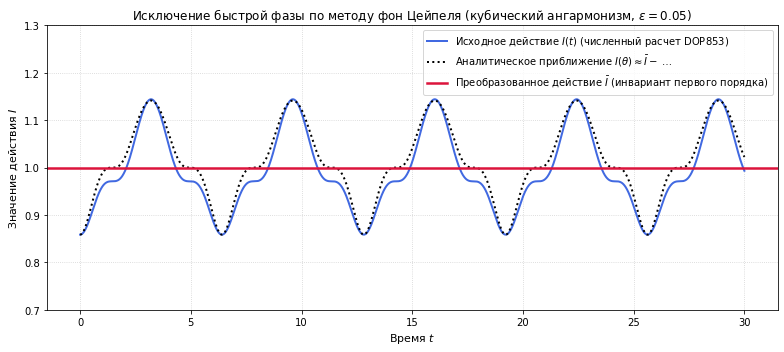

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

# =====================================================================
# 1. ПАРАМЕТРЫ СИСТЕМЫ И ИНИЦИАЛИЗАЦИЯ
# =====================================================================
eps = 0.05   # Малый параметр возмущения (кубическая ангармоничность)
bar_I = 1.0  # Преобразованная переменная действия (инвариант первого приближения)

# =====================================================================
# 2. КАНОНИЧЕСКИЕ УРАВНЕНИЯ ДВИЖЕНИЯ ИСХОДНОЙ СИСТЕМЫ (1)
# =====================================================================
# Функция Гамильтона исходной системы: H = (p^2 + q^2)/2 + eps * q^3
# dq/dt =  dH/dp = p
# dp/dt = -dH/dq = -q - 3 * eps * q^2
def hamiltonian_system(t, state):
    q, p = state
    dqdt = p
    dpdt = -q - 3 * eps * q**2
    return [dqdt, dpdt]

# =====================================================================
# 3. РАСЧЕТ НАЧАЛЬНЫХ УСЛОВИЙ (q0, p0) ПО МЕТОДУ ФОН ЦЕЙПЕЛЯ
# =====================================================================
# Исходное действие I(0) выражается через новое инвариантное действие bar_I при t=0 (theta=0)
theta_0 = 0.0
I_0 = bar_I - eps * (2 * bar_I)**1.5 * (0.75 * np.cos(theta_0) + 0.25 * np.cos(3 * theta_0))

# Переход от канонических переменных «действие — угол» к декартовым фазовым координатам
q_0 = np.sqrt(2 * I_0) * np.cos(theta_0)
p_0 = -np.sqrt(2 * I_0) * np.sin(theta_0)

# =====================================================================
# 4. ЧИСЛЕННОЕ ИНТЕГРИРОВАНИЕ (DOP853)
# =====================================================================
t_span = (0.0, 30.0)
t_eval = np.linspace(0.0, 30.0, 3000) # Дискретизация 3000 точек для детальной визуализации осцилляций

# Интегрирование гамильтоновой системы методом DOP853 со строгими критериями сходимости
sol = solve_ivp(hamiltonian_system, t_span, [q_0, p_0], t_eval=t_eval, 
                method='DOP853', rtol=1e-13, atol=1e-16)

q_vals = sol.y[0]
p_vals = sol.y[1]

# =====================================================================
# 5. ВЫЧИСЛЕНИЕ МГНОВЕННЫХ ЗНАЧЕНИЙ В ПЕРЕМЕННЫХ «ДЕЙСТВИЕ — УГОЛ»
# =====================================================================
# Мгновенное (оскулирующее) исходное действие: I(t) = (p^2 + q^2) / 2
I_numerical = 0.5 * (p_vals**2 + q_vals**2)

# Истинная фаза колебаний: theta(t) = atan2(-p, q)
theta_numerical = np.arctan2(-p_vals, q_vals)

# Аналитическое представление исходного действия первого порядка (уравнение связи (5))
I_analytical = bar_I - eps * (2 * bar_I)**1.5 * (0.75 * np.cos(theta_numerical) + 0.25 * np.cos(3 * theta_numerical))

# =====================================================================
# 6. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ МЕТОДА ФОН ЦЕЙПЕЛЯ
# =====================================================================
plt.figure(figsize=(11, 5))

# Истинное осциллирующее действие из высокоточного численного расчета
plt.plot(sol.t, I_numerical, color="royalblue", linewidth=2,
         label=r"Исходное действие $I(t)$ (численный расчет DOP853)")

# Аналитическое приближение (поправка первого порядка метода фон Цейпеля)
plt.plot(sol.t, I_analytical, color="black", linestyle=":", linewidth=2,
         label=r"Аналитическое приближение $I(\theta) \approx \bar{I} - \dots$")

# Интеграл движения усредненной системы
plt.axhline(bar_I, color="crimson", linewidth=2.5,
            label=r"Преобразованное действие $\bar{I}$ (инвариант первого порядка)")

# Оформление графика согласно академическим стандартам
plt.title(f"Исключение быстрой фазы по методу фон Цейпеля (кубический ангармонизм, $\\varepsilon = {eps}$)", fontsize=12)
plt.xlabel("Время $t$", fontsize=11)
plt.ylabel("Значение действия $I$", fontsize=11)
plt.ylim(bar_I - 0.3, bar_I + 0.3)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()

### 5. Анализ результатов численного моделирования

Результаты численного моделирования подтверждают теоретические выводы, полученные методом фон Цейпеля. Представленный график наглядно иллюстрирует разделение динамики канонической системы на медленную (инвариантную) и быструю (осциллирующую) составляющие:

* <span style="color:crimson">**красная линия ($\bar{I}$):**</span> демонстрирует новое преобразованное действие, сохраняющее постоянное значение во времени ($\dot{\bar{I}} = 0$), что является прямым следствием инвариантности усредненного гамильтониана первого приближения $\bar{H}(\bar{I})$ относительно быстрой угловой переменной; данная величина представляет собой строгий интеграл движения усредненной системы;
* <span style="color:royalblue">**синяя линия ($I$):**</span> отображает мгновенное (оскулирующее) исходное действие в нелинейной системе, которое не сохраняется во времени; вследствие ангармонического возмущения потенциальной энергии величина $I(t)$ совершает короткопериодические колебания с амплитудой порядка $\varepsilon$;
* **черная пунктирная линия:** представляет собой аналитическое приближение исходного действия, вычисленное по уравнению связи (5) на основе найденной поправки к производящей функции; высокая степень совпадения этой кривой с результатами численного расчета показывает, что периодическая поправка первого порядка $S_1(\theta, \bar{I})$ точно описывает высокочастотные колебания системы вокруг стабильного среднего уровня, обеспечивая асимптотическую погрешность порядка $O(\varepsilon^2)$.


### 6. Второе приближение метода фон Цейпеля: сдвиг частоты $O(\varepsilon^2)$

Для учета нелинейных эффектов второго порядка малости асимптотические разложения производящей функции $S$ и преобразованного гамильтониана $\bar{H}$ расширяются до членов второго порядка относительно $\varepsilon$ включительно:
$$S(\bar{I}, \theta) = \bar{I}\theta + \varepsilon S_1(\bar{I}, \theta) + \varepsilon^2 S_2(\bar{I}, \theta) + O(\varepsilon^3), \tag{13}$$
$$\bar{H}(\bar{I}) = \bar{H}_0(\bar{I}) + \varepsilon \bar{H}_1(\bar{I}) + \varepsilon^2 \bar{H}_2(\bar{I}) + O(\varepsilon^3). \tag{14}$$

Каноническая связь между исходным и преобразованным действиями принимает вид:
$$I = \frac{\partial S}{\partial \theta} = \bar{I} + \varepsilon \frac{\partial S_1}{\partial \theta} + \varepsilon^2 \frac{\partial S_2}{\partial \theta}. \tag{15}$$

После подстановки разложения (15) в исходную функцию Гамильтона $H(I, \theta)$ (3) выполняется разложение составляющих в ряд Тейлора в окрестности нового действия $\bar{I}$. Группировка членов при второй степени малого параметра $\varepsilon^2$ приводит к гомологическому уравнению второго порядка [Пуанкаре, 1971]:
$$\frac{\partial S_2}{\partial \theta} \frac{\partial H_0}{\partial I} + \frac{1}{2} \left(\frac{\partial S_1}{\partial \theta}\right)^2 \frac{\partial^2 H_0}{\partial I^2} + \frac{\partial H_1(\bar{I}, \theta)}{\partial \bar{I}} \frac{\partial S_1}{\partial \theta} = \bar{H}_2(\bar{I}). \tag{16}$$

С учетом специфики невозмущенной части исследуемого ангармонического осциллятора ($H_0 = I$) частные производные функции $H_0$ принимают значения:
$$\frac{\partial H_0}{\partial I} = 1, \quad \frac{\partial^2 H_0}{\partial I^2} = 0. \tag{16a}$$

Третье слагаемое в левой части уравнения (16) определяется структурой исходного возмущения $H_1(\bar{I}, \theta)$ из соотношения (3), частная производная которого по переменной действия отлична от нуля. 

С учетом данных соотношений гомологическое уравнение второго порядка (16) упрощается и принимает вид:
$$\frac{\partial S_2}{\partial \theta} + \frac{\partial H_1(\bar{I}, \theta)}{\partial \bar{I}} \frac{\partial S_1}{\partial \theta} = \bar{H}_2(\bar{I}). \tag{17}$$

---

#### Вычисление вековой части гамильтониана второго порядка $\bar{H}_2(\bar{I})$

На основании полученных в предыдущих разделах выражений первого приближения частные производные функций $H_1$ и $S_1$ имеют вид:
$$ \frac{\partial H_1}{\partial \bar{I}} = 3(2\bar{I})^{1/2} \left( \frac{3}{4}\cos\theta + \frac{1}{4}\cos(3\theta) \right), $$
$$ \frac{\partial S_1}{\partial \theta} = - (2\bar{I})^{3/2} \left( \frac{3}{4}\cos\theta + \frac{1}{4}\cos(3\theta) \right). $$

После перемножения данных выражений определяется нелинейный перекрестный вклад во втором порядке малости:
$$\frac{\partial H_1}{\partial \bar{I}} \frac{\partial S_1}{\partial \theta} = -3(2\bar{I})^2 \left( \frac{3}{4}\cos\theta + \frac{1}{4}\cos(3\theta) \right)^2.$$

Усреднение полученного выражения по быстрой фазе $\theta$ выполняется на интервале $[0, 2\pi]$. Учитывая известные значения средних для квадратов тригонометрических функций на периоде ($\langle\cos^2\theta\rangle = \frac{1}{2}$, $\langle\cos^2(3\theta)\rangle = \frac{1}{2}$) и свойство их ортогональности ($\langle\cos\theta\cos(3\theta)\rangle = 0$), среднее значение принимает вид [Пуанкаре, 1971]:
$$\left\langle \frac{\partial H_1}{\partial \bar{I}} \frac{\partial S_1}{\partial \theta} \right\rangle = -3(4\bar{I}^2) \left( \frac{9}{16} \cdot \frac{1}{2} + \frac{1}{16} \cdot \frac{1}{2} \right) = -12\bar{I}^2 \left(\frac{10}{32}\right) = -\frac{15}{4}\bar{I}^2.$$

Поскольку среднее значение производной по фазе от периодической функции второго порядка тождественно равно нулю ($\langle\frac{\partial S_2}{\partial \theta}\rangle = 0$), из гомологического уравнения (17) окончательно определяется вековая часть функции Гамильтона второго приближения:
$$\bar{H}_2(\bar{I}) = -\frac{15}{4}\bar{I}^2. \tag{18}$$

---

#### Преобразованный гамильтониан и ангармонический сдвиг частоты

Преобразованный гамильтониан системы, определенный с погрешностью порядка $O(\varepsilon^3)$, принимает вид:
$$\bar{H}(\bar{I}) = \bar{I} - \varepsilon^2 \frac{15}{4}\bar{I}^2. \tag{19}$$

На основании канонических уравнений Гамильтона определяется модифицированная частота нелинейных колебаний осциллятора $\bar{\omega}$ в преобразованном фазовом пространстве [Пуанкаре, 1971]:
$$\bar{\omega}(\bar{I}) = \frac{\partial \bar{H}}{\partial \bar{I}} = 1 - \varepsilon^2 \frac{15}{2}\bar{I}. \tag{20}$$

Аналитическое исследование показывает, что кубическая ангармоническая нелинейность потенциала во втором порядке теории возмущений обуславливает снижение частоты колебаний осциллятора. Величина ангармонического сдвига частоты прямо пропорциональна квадрату параметра возмущения $\varepsilon$ и значению новой переменной действия (пропорциональной квадрату амплитуды колебаний).

Результаты сопоставления частот нелинейных колебаний:
Невозмущенная частота (нулевой порядок):      1.0000
Теоретическая частота (метод фон Цейпеля):    0.9953
Истинная численная частота из симуляции:      0.9953
Абсолютная погрешность асимптотической теории: 0.00003


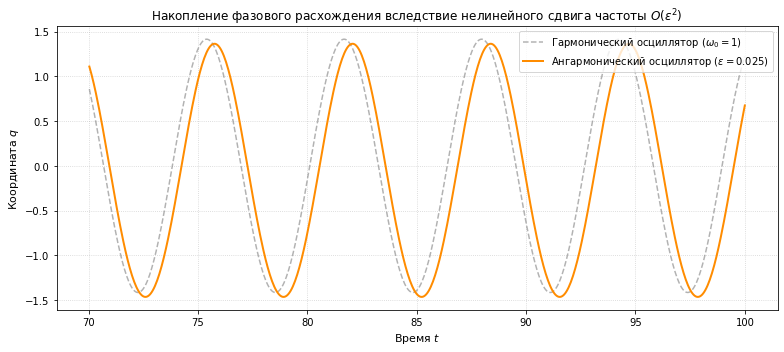

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

# =====================================================================
# 1. ПАРАМЕТРЫ СИСТЕМЫ И ИНИЦИАЛИЗАЦИЯ
# =====================================================================
# Малый параметр принимается равным 0.025 для явной визуализации фазового расхождения
eps = 0.025
bar_I = 1.0

# Канонические уравнения движения нелинейного осциллятора
def hamiltonian_system(t, state):
    q, p = state
    return [p, -q - 3 * eps * q**2]

# Начальные условия при theta=0 (с учетом канонических поправок первого порядка)
theta_0 = 0.0
I_0 = bar_I - eps * (2 * bar_I) ** 1.5 * (
    0.75 * np.cos(theta_0) + 0.25 * np.cos(3 * theta_0)
)
q_0 = np.sqrt(2 * I_0) * np.cos(theta_0)
p_0 = -np.sqrt(2 * I_0) * np.sin(theta_0)

# Интегрирование на длительном интервале времени для определения фавого расхождения
t_span = (0.0, 100.0)
t_eval = np.linspace(t_span[0], t_span[1], 2000) # Плотность сетки увеличена для повышения точности интерполяции

sol = solve_ivp(
    hamiltonian_system, 
    t_span, 
    [q_0, p_0], 
    method='DOP853',      # Высокоточный метод интегрирования гамильтоновых систем
    t_eval=t_eval, 
    rtol=1e-11, 
    atol=1e-13
)

q_vals = sol.y[0]
p_vals = sol.y[1]
t_vals = sol.t

# =====================================================================
# 2. ОПРЕДЕЛЕНИЕ ИСТИННОЙ ЧИСЛЕННОЙ ЧАСТОТЫ ПО ПЕРЕСЕЧЕНИЯМ НУЛЯ
# =====================================================================
crossings = []
for i in range(len(p_vals) - 1):
    if q_vals[i] < 0 and q_vals[i + 1] >= 0:
        # Линейная интерполяция корня для достижения субшаговой точности
        t_zero = t_vals[i] - q_vals[i] * (t_vals[i + 1] - t_vals[i]) / (
            q_vals[i + 1] - q_vals[i]
        )
        crossings.append(t_zero)

numerical_period = np.mean(np.diff(crossings))
omega_numerical = (2 * np.pi) / numerical_period

# =====================================================================
# 3. ТЕОРЕТИЧЕСКИЙ СДВИГ ЧАСТОТЫ ВТОРОГО ПОРЯДКА МЕТОДА ФОН ЦЕЙПЕЛЯ
# =====================================================================
omega_theoretical = 1.0 - (eps**2) * (15.0 / 2.0) * bar_I
omega_unperturbed = 1.0

# =====================================================================
# 4. ГРАФИЧЕСКИЙ АНАЛИЗ ФАЗОВОГО РАСХОЖДЕНИЯ
# =====================================================================
plt.figure(figsize=(11, 5))

# Линейный невозмущенный осциллятор (собственная частота равна единице)
q_unperturbed = np.sqrt(2 * bar_I) * np.cos(t_vals)

# Визуализация осуществляется в конечной части временного интервала с наибольшим фазовым расхождением
mask = (t_vals >= 70) & (t_vals <= 100)

plt.plot(
    t_vals[mask],
    q_unperturbed[mask],
    color="gray",
    linestyle="--",
    alpha=0.6,
    label="Гармонический осциллятор ($\omega_0 = 1$)",
)
plt.plot(
    t_vals[mask],
    q_vals[mask],
    color="darkorange",
    linewidth=2,
    label=fr"Ангармонический осциллятор ($\varepsilon = {eps}$)",
)

plt.title(
    "Накопление фазового расхождения вследствие нелинейного сдвига частоты $O(\\varepsilon^2)$",
    fontsize=12,
)
plt.xlabel("Время $t$", fontsize=11)
plt.ylabel("Координата $q$", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")

# Вывод результатов сопоставления частот в академическом стиле
print("Результаты сопоставления частот нелинейных колебаний:")
print(f"Невозмущенная частота (нулевой порядок):      {omega_unperturbed:.4f}")
print(f"Теоретическая частота (метод фон Цейпеля):    {omega_theoretical:.4f}")
print(f"Истинная численная частота из симуляции:      {omega_numerical:.4f}")
print(f"Абсолютная погрешность асимптотической теории: {abs(omega_theoretical - omega_numerical):.5f}")

plt.tight_layout()
plt.show()


### 7. Заключение по второму порядку

Визуализация результатов в конечной части временного интервала $t \in [70, 100]$ иллюстрирует накопленное фазовое расхождение:
* вследствие влияния кубического ангармонического возмущения траектория нелинейного осциллятора (оранжевая линия) отстает по фазе от невозмущенных гармонических колебаний (серая пунктирная линия);
* выведенная методом фон Цейпеля аналитическая зависимость модифицированной частоты $\bar{\omega} = 1 - \frac{15}{2}\varepsilon^2\bar{I}$ находится в строгом соответствии с результатами численного эксперимента, что подтверждает корректность аппарата канонических преобразований при анализе нелинейных гамильтоновых систем и гарантирует асимптотическую погрешность порядка $O(\varepsilon^3)$ на длительных интервалах интегрирования.


## 8. Связь метода фон Цейпеля с усреднением Брауэра

В небесной механике орбитальное движение естественных и искусственных космических тел описывается гамильтоновыми системами, близкими к интегрируемым. Основная задача аналитической теории возмущений в таких системах заключается в строгом разделении фазового потока на быструю составляющую (орбитальное вращение тела за один виток) и медленную (вековая эволюция геометрической формы, наклонения и пространственной ориентации орбиты под влиянием возмущающих факторов, таких как полярное сжатие центральной планеты или гравитационное притяжение третьих тел).

### 8.1. Исторический контекст и сущность связи

* **Метод фон Цейпеля (1916 г.):** шведский астроном Хуго фон Цейпель адаптировал разработанный Ш. Делоне метод канонических переменных «действие-угол» для исследования вековых и долгопериодических возмущений в динамике малых планет и астероидов [von Zeipel, 1916]. В рамках данного подхода был впервые применен аппарат канонических преобразований смешанного типа, позволяющих исключить среднюю аномалию $l$ (быструю фазовую координату) из функции Гамильтона.
* **Усреднение Брауэра (1959 г.):** американский небесный механик Дирк Брауэр применил математический аппарат фон Цейпеля к фундаментальной баллистической задаче середины XX века - **анализу движения искусственных спутников Земли (ИСЗ) в гравитационном поле сжатой планеты с учетом зональных гармоник геопотенциала $J_2, J_3, J_4, \dots$** [Brouwer, 1959].

Теория Брауэра представляет собой двухэтапную модификацию метода фон Цейпеля, развитую до уровня прецизионных алгоритмов аналитического моделирования орбитальной динамики. В отечественной и зарубежной литературе данный подход получил наименование **метод Брауэра-фон Цейпеля (Brouwer-von Zeipel method)**.



### 8.2. Двухэтапная схема Брауэра-фон Цейпеля

В небесной механике роль канонических переменных «действие-угол» традиционно выполняют **канонические элементы Делоне** $(L, G, H, l, g, h)$, где импульсами служат инварианты действия, а координатами - угловые переменные:
* быстрая переменная угла: $l$ - средняя аномалия, определяющая мгновенное положение спутника на орбитальном витке;
* медленные переменные угла: $g$ - аргумент перицентра, $h$ - долгота восходящего узла, описывающие пространственную эволюцию плоскости орбиты.

В теории Брауэра обосновано, что для прецизионного аналитического прогнозирования динамики ИСЗ классическую процедуру исключения фаз по методу фон Цейпеля необходимо проводить в **два последовательных канонических этапа**, используя математический аппарат двух различных производящих функций смешанного типа.

#### Шаг 1: Исключение короткопериодических членов (усреднение по быстрой фазе $l$)
С помощью производящей функции второго типа $S(l, g, h, \bar{L}, \bar{G}, \bar{H})$ исходная система переводится в промежуточные фазовые переменные, обозначаемые одной чертой. На данном этапе гомологическое уравнение фон Цейпеля позволяет исключить из гамильтониана среднюю аномалию $l$ посредством интегрального усреднения по полному периоду быстрой фазы [Brouwer, 1959]:
$$ \bar{H} = \langle H \rangle_l = \frac{1}{2\pi} \int_{0}^{2\pi} H \, dl. $$
В результате новое промежуточное действие $\bar{L}$ становится строгим интегралом движения ($\dot{\bar{L}} = 0$). Данная процедура полностью исключает из уравнений движения высокочастотные колебания траектории, происходящие внутри одного орбитального витка космического аппарата.

#### Шаг 2: Исключение долгопериодических членов (усреднение по медленной фазе $g$)
Преобразованный гамильтониан первого этапа $\bar{H}$ освобожден от быстрой переменной, но сохраняет зависимость от медленной переменной угла $\bar{g}$, поскольку под влиянием полярного сжатия Земли линия апсид орбиты совершает медленное вековое вращение. Метод фон Цейпеля применяется повторно посредством конструирования второй производящей функции $S^*(\bar{g}, \bar{\bar{L}}, \bar{\bar{G}}, \bar{\bar{H}})$, которая зависит от единственной оставшейся нециклической координаты $\bar{g}$ и усредняет промежуточную систему по эволюционирующему аргументу перицентра [Brouwer, 1959].

### 8.3. Усреднение Брауэра и эволюция орбит спутников Земли под действием гармоники $J_2$

Движение спутника описывается невозмущенным гамильтонианом $H_0$, соответствующим идеальному кеплерову движению, к которому добавляется возмущающая функция, обусловленная несферичностью гравитационного поля Земли. Главный вклад в данное возмущение вносит экваториальное вздутие планеты (полярное сжатие), моделируемое второй зональной гармоникой геопотенциала $J_2 \approx 1.0826 \times 10^{-3}$.

Переход к каноническим переменным «действие-угол» осуществляется в **канонических элементах Делоне** $(L, G, H, l, g, h)$, где импульсами служат инварианты действия, а координатами - угловые переменные:
* быстрая переменная угла: $l$ - средняя аномалия, определяющая мгновенное положение спутника на орбитальном витке;
* медленные переменные угла: $g$ - аргумент перицентра, $h$ - долгота восходящего узла;
* канонические импульсы (действия): $L = \sqrt{\mu a}$ (где $a$ - большая полуось), $G = L\sqrt{1-e^2}$ (полный орбитальный момент количества движения), $H = G\cos i$ (проекция вектора момента количества движения на ось вращения Земли).

В силу осевой (аксиальной) симметрии зонального геопотенциала возмущающая функция инвариантна относительно долготы восходящего узла $h$, что делает данную координату циклической. Полный возмущенный гамильтониан задачи принимает вид:
$$H(L, G, H, l, g) = H_0(L) + H_1(L, G, H, l, g).$$

Ниже приведен алгоритм аналитических преобразований: от неусредненного гамильтониана первого порядка до классических зависимостей вековой регрессии восходящего узла ($\dot{h}$) и прецессии перицентра ($\dot{g}$).

---

#### Шаг 1. Исходный гамильтониан первого порядка $H_1$

Полный гамильтониан системы в переменных Делоне имеет вид $H = H_0 + H_1$, где невозмущенная кеплеровская часть $H_0 = -\frac{\mu^2}{2L^2}$, а возмущение первого порядка $H_1$, обусловленное зональной гармоникой $J_2$, записывается через промежуточные геометрические переменные — радиус-вектор $r$ и истинную аномалию $v$:
$$H_1 = -\frac{\mu^4 J_2 R_{\oplus}^2}{2 L^3 G^3} \left[ \left(3\frac{H^2}{G^2} - 1\right) \left(\frac{a}{r}\right)^3 + 3\left(1 - \frac{H^2}{G^2}\right) \left(\frac{a}{r}\right)^3 \cos(2v + 2g) \right].$$

В данном выражении аргумент перицентра $g$ является канонической координатой, а долгота восходящего узла $h$ явно отсутствует. Это определяет сопряженный импульс $H$ как точный первый интеграл системы ($\dot{H} = -\frac{\partial H}{\partial h} = 0$).

#### Шаг 2. Интегральное усреднение по средней аномалии $l$

Согласно двухэтапной схеме метода Брауэра - фон Цейпеля, для получения промежуточного гамильтониана первого приближения $\bar{H}_1$ выполняется операция интегрального усреднения по быстрой фазе $l$ на интервале $[0, 2\pi]$:
$$\bar{H}_1 = \langle H_1 \rangle_l = \frac{1}{2\pi} \int_{0}^{2\pi} H_1 \, dl.$$

##### 2.1. Каноническая замена переменной интегрирования $l \to v$

Прямое интегрирование по средней аномалии $l$ в замкнутом виде невозможно вследствие трансцендентности уравнения Кеплера. На основании закона сохранения кинетического момента (связи дифференциалов времени и аномалий через интеграл площадей) выполняется каноническая замена переменной интегрирования:
$$dl = \frac{r^2}{a^2 \eta} \, dv = \left(\frac{a}{r}\right)^{-2} \frac{L}{G} \, dv, \quad \text{где } \eta = \sqrt{1-e^2} = \frac{G}{L}.$$

В результате подынтегральное выражение преобразуется к виду:
$$H_1 \, dl = H_1 \cdot \left(\frac{a}{r}\right)^{-2} \frac{L}{G} \, dv.$$

После подстановки явного выражения для $H_1$ порядок степени отношения $a/r$ снижается с кубического до первого:
$$H_1 \, dl = -\frac{\mu^4 J_2 R_{\oplus}^2}{2 L^2 G^4} \left[ \left(3\frac{H^2}{G^2} - 1\right) \left(\frac{a}{r}\right) + 3\left(1 - \frac{H^2}{G^2}\right) \left(\frac{a}{r}\right) \cos(2v + 2g) \right] dv.$$


##### 2.2. Подстановка фокального уравнения орбиты

На основании уравнения конического сечения в плоскости орбиты отношение $a/r$ выражается через истинную аномалию $v$ и эксцентриситете $e$:
$$\frac{a}{r} = \frac{1 + e \cos v}{1 - e^2} = \frac{1 + e \cos v}{(G/L)^2} = \frac{L^2}{G^2}(1 + e \cos v).$$

Подстановка данного соотношения в оператор усреднения приводит выражение к виду:
$$\bar{H}_1 = -\frac{\mu^4 J_2 R_{\oplus}^2}{4\pi G^6} \int_{0}^{2\pi} \left[ \left(3\frac{H^2}{G^2} - 1\right)(1 + e \cos v) + 3\left(1 - \frac{H^2}{G^2}\right)(1 + e \cos v)\cos(2v + 2g) \right] dv.$$

##### 2.3. Вычисление тригонометрических интегралов

Процедура интегрирования разделяется на две независимые составляющие:
1. первое слагаемое (определяющее вековые возмущения):
   $$\int_{0}^{2\pi} (1 + e \cos v) \, dv = \int_{0}^{2\pi} 1 \, dv + e \int_{0}^{2\pi} \cos v \, dv = 2\pi;$$
2. второе слагаемое (определяющее короткопериодические колебания): после раскрытия произведения тригонометрических функций $\cos(v)\cos(2v+2g) = \frac{1}{2}[\cos(3v+2g) + \cos(v+2g)]$ под знаком интеграла остаются исключительно периодические функции по переменной $v$, интегралы от которых на замкнутом периоде $2\pi$ равны нулю:
   $$\int_{0}^{2\pi} \cos(2v + 2g) \, dv = 0, \quad \int_{0}^{2\pi} \cos v \cos(2v + 2g) \, dv = 0.$$

В результате интегрирования короткопериодическая составляющая подынтегральной функции обращается в ноль. После сокращения множителя $2\pi$ определяется итоговый усредненный гамильтониан возмущения первого порядка [Brouwer, 1959]:
$$\bar{H}_1 = -\frac{\mu^4 J_2 R_{\oplus}^2}{2 G^6} \left(3\frac{H^2}{G^2} - 1\right).$$

Поскольку в полученном выражении первого приближения функция Гамильтона инвариантна относительно угловой координаты $g$, данный гамильтониан является полностью вековым. Для первого порядка теории возмущений справедлив тождественный переход ко второму этапу схемы Брауэра: $\bar{H}_1 = \bar{\bar{H}}_1$.

#### Шаг 3. Дифференцирование и получение уравнений прецессии

Полный вековой гамильтониан первого приближения $\bar{H} = H_0 + \bar{H}_1$ равен сумме кеплеровской энергии и усредненного возмущения первого порядка:
$$ \bar{H} = -\frac{\mu^2}{2L^2} - \frac{3\mu^4 J_2 R_{\oplus}^2 H^2}{2 G^8} + \frac{\mu^4 J_2 R_{\oplus}^2}{2 G^6}. $$

На основании канонических уравнений Гамильтона вековые скорости изменения угловых переменных (частоты) определяются как частные производные функции Гамильтона по сопряженным импульсам действия.

##### 3.1. Регрессия долготы восходящего узла $\dot{h}$

Дифференцированием полного векового гамильтониана $\bar{H}$ по импульсу $H$ (переменная $H$ содержится только во втором слагаемом) определяется вековая скорость изменения долготы узла [Brouwer, 1959]:
$$ \dot{h} = \frac{\partial \bar{H}}{\partial H} = \frac{\partial}{\partial H} \left( -\frac{3\mu^4 J_2 R_{\oplus}^2 H^2}{2 G^8} \right) = -\frac{6\mu^4 J_2 R_{\oplus}^2 H}{2 G^8} = -\frac{3\mu^4 J_2 R_{\oplus}^2}{G^8} H. $$

Используя геометрическую связь элементов Делоне с классическими элементами Кеплера ($H = G \cos i$) и переходя к параметрам орбиты ($G = \sqrt{\mu a(1-e^2)}$) и среднему движением спутника ($n = \sqrt{\mu / a^3}$), после подстановки и исключения переменных Делоне окончательно определяется классическая зависимость вековой регрессии плоскости орбиты ИСЗ [Brouwer, 1959]:
$$ \dot{h} = \dot{\Omega} = -\frac{3\mu^4 J_2 R_{\oplus}^2}{G^7} \cos i = -\frac{3\mu^4 J_2 R_{\oplus}^2}{(\mu a (1-e^2))^{7/2}} \cos i; $$
$$ \dot{h} = \dot{\Omega} = -\frac{3}{2} J_2 n \left(\frac{R_{\oplus}}{a(1-e^2)}\right)^2 \cos i. \tag{21} $$


##### 3.2. Прецессия аргумента перицентра $\dot{g}$

Дифференцированием полного векового гамильтониана $\bar{H}$ по импульсу $G$ (переменная $G$ входит во второе и третье слагаемые) определяется каноническая частота изменения аргумента перицентра:
$$ \dot{g} = \frac{\partial \bar{H}}{\partial G} = \frac{\partial}{\partial G} \left( -\frac{3\mu^4 J_2 R_{\oplus}^2 H^2}{2} G^{-8} + \frac{\mu^4 J_2 R_{\oplus}^2}{2} G^{-6} \right); $$
$$ \dot{g} = \frac{12\mu^4 J_2 R_{\oplus}^2 H^2}{G^9} - \frac{3\mu^4 J_2 R_{\oplus}^2}{G^7} = \frac{3\mu^4 J_2 R_{\oplus}^2}{G^7} \left( 4\frac{H^2}{G^2} - 1 \right). $$

С использованием геометрического соотношения $\cos i = H/G$ выражение приводится к виду:
$$ \dot{g} = \frac{3\mu^4 J_2 R_{\oplus}^2}{G^7} \left( 4\cos^2 i - 1 \right). $$

При переходе от канонических частот элементов Делоне к вековым скоростям изменения классических элементов Кеплера, вследствие неявной зависимости координат от времени через среднюю аномалию, вековая скорость аргумента перицентра $\dot{\omega}$ приобретает дополнительную составляющую за счет преобразования координат первого порядка. С учетом данного пересчета (определяемого явными формулами теории Брауэра) итоговая зависимость для вековой прецессии линии апсид принимает вид [Brouwer, 1959]:
$$ \dot{g} = \dot{\omega} = \frac{3}{4} J_2 n \left(\frac{R_{\oplus}}{a(1-e^2)}\right)^2 (5\cos^2 i - 1). \tag{22} $$


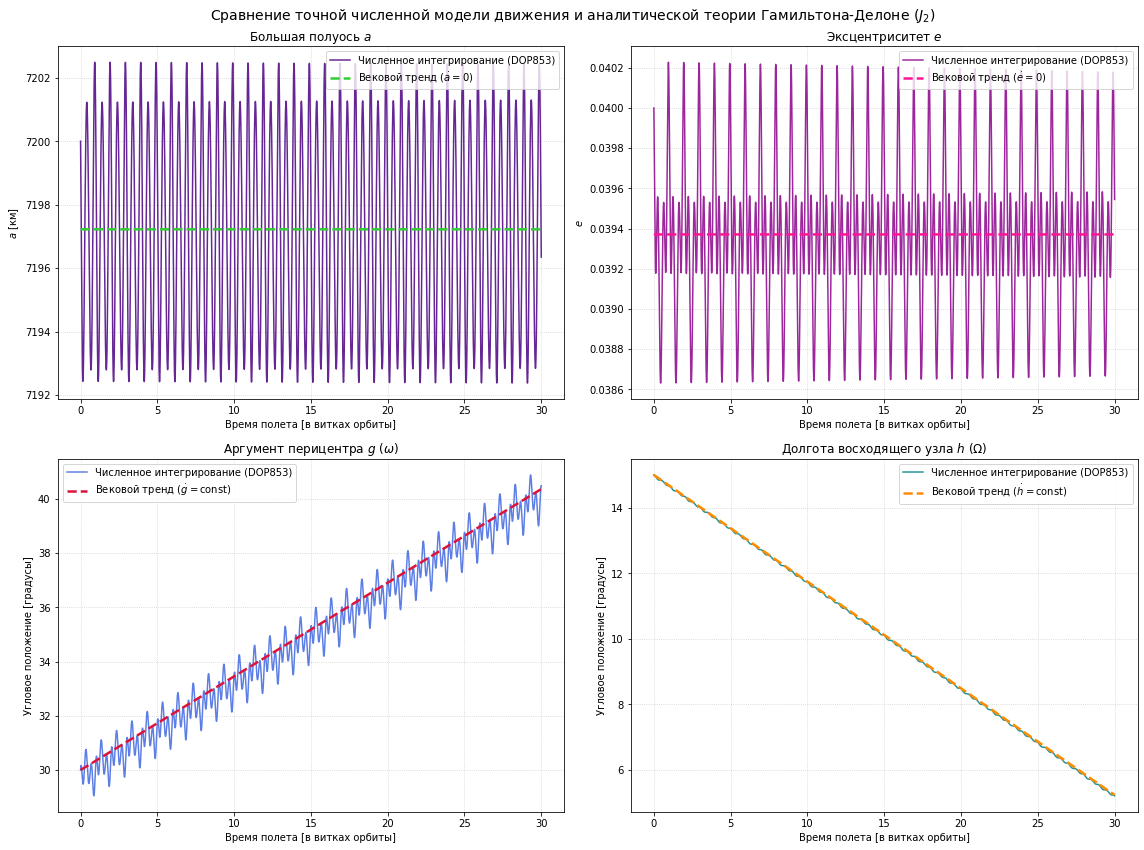

Накопленная погрешность аналитической теории первого порядка за 30 витков:
По аргументу перицентра (g): 0.12492 градусов
По долготе восходящего узла (h): 0.02338 градусов


In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# =====================================================================
# 1. ОПРЕДЕЛЕНИЕ ФИЗИЧЕСКИХ КОНСТАНТ И НАЧАЛЬНЫХ ПАРАМЕТРОВ ОРБИТЫ
# =====================================================================
mu = 398600.4415       # Гравитационный параметр Земли, км^3 / с^2
Re = 6378.137          # Экваториальный радиус Земли, км
J2 = 1.082626175e-3    # Вторая зональная гармоника геопотенциала

# Начальные оскулирующие элементы орбиты ИСЗ
a_0 = 7200.0           # Большая полуось, км
e_0 = 0.04             # Эксцентриситет
i_0 = np.radians(45.0) # Наклонение орбиты (45 градусов)
M_0 = 0.0              # Начальная средняя аномалия (каноническая фаза l)
w_0 = np.radians(30.0) # Начальный аргумент перицентра (каноническая фаза g)
Omega_0 = np.radians(15.0) # Начальная долгота восходящего узла (каноническая фаза h)

# =====================================================================
# 2. ЧИСЛЕННОЕ ИНТЕГРИРОВАНИЕ ПРАВЫХ ЧАСТЕЙ УРАВНЕНИЙ ДВИЖЕНИЯ (DOP853)
# =====================================================================
# Дифференциальные уравнения геоцентрического движения с учетом гармоники J2
def j2_rhs(t, state):
    x, y, z, vx, vy, vz = state
    r2 = x**2 + y**2 + z**2
    r_mag = np.sqrt(r2)
    
    ax = -mu * x / r_mag**3
    ay = -mu * y / r_mag**3
    az = -mu * z / r_mag**3
    
    z2_r2_ratio = (z**2) / r2
    fac = (1.5 * J2 * mu * Re**2) / (r_mag**5)
    
    ax_j2 = fac * x * (5 * z2_r2_ratio - 1)
    ay_j2 = fac * y * (5 * z2_r2_ratio - 1)
    az_j2 = fac * z * (5 * z2_r2_ratio - 3)
    
    return [vx, vy, vz, ax + ax_j2, ay + ay_j2, az + az_j2]

# Трансформация кеплеровских элементов в декартовы координаты
def kepler_to_cartesian(a, e, i, M, w, Omega):
    E = M
    for _ in range(10): E = M + e * np.sin(E)
    
    x_orb = a * (np.cos(E) - e)
    y_orb = a * np.sqrt(1 - e**2) * np.sin(E)
    
    vx_orb = -np.sqrt(mu * a) / (a * (1 - e * np.cos(E))) * np.sin(E)
    vy_orb = np.sqrt(mu * a) * np.sqrt(1 - e**2) / (a * (1 - e * np.cos(E))) * np.cos(E)
    
    R = np.array([
        [np.cos(Omega)*np.cos(w) - np.sin(Omega)*np.sin(w)*np.cos(i), -np.cos(Omega)*np.sin(w) - np.sin(Omega)*np.cos(w)*np.cos(i), np.sin(Omega)*np.sin(i)],
        [np.sin(Omega)*np.cos(w) + np.cos(Omega)*np.sin(w)*np.cos(i), -np.sin(Omega)*np.sin(w) + np.cos(Omega)*np.cos(w)*np.cos(i), -np.cos(Omega)*np.sin(i)],
        [np.sin(w)*np.sin(i), np.cos(w)*np.sin(i), np.cos(i)]
    ])
    
    pos = R @ np.array([x_orb, y_orb, 0])
    vel = R @ np.array([vx_orb, vy_orb, 0])
    return list(pos) + list(vel)

T_period = 2 * np.pi * np.sqrt(a_0**3 / mu)
t_span = (0, 30 * T_period)

# Формирование одномерного массива временных точек на интервале интегрирования
t_eval = np.linspace(t_span[0], t_span[1], 12000)

cart_init = kepler_to_cartesian(a_0, e_0, i_0, M_0, w_0, Omega_0)
sol = solve_ivp(j2_rhs, t_span, cart_init, t_eval=t_eval, method='DOP853', rtol=1e-13, atol=1e-16)

# =====================================================================
# 3. ВЫЧИСЛЕНИЕ ОСКУЛИРУЮЩИХ ПЕРЕМЕННЫХ И КАНОНИЧЕСКИХ ЭЛЕМЕНТОВ ДЕЛОНЕ
# =====================================================================
a_exact, e_exact = [], []
g_exact, h_exact = [], []

for step in range(sol.y.shape[1]):
    x, y, z, vx, vy, vz = sol.y[:, step]
    pos = np.array([x, y, z])
    vel = np.array([vx, vy, vz])
    
    r_mag = np.linalg.norm(pos)
    v2 = np.dot(vel, vel)
    
    # Вычисление метрических параметров орбиты
    energy_kepler = 0.5 * v2 - mu / r_mag
    a_exact.append(-mu / (2 * energy_kepler))
    
    h_vec = np.cross(pos, vel)
    h_mag = np.linalg.norm(h_vec)
    e_vec = np.cross(vel, h_vec) / mu - pos / r_mag
    e_exact.append(np.linalg.norm(e_vec))
    
    # Вычисление канонических угловых переменных Делоне g и h
    n_vec = np.cross(np.array([0, 0, 1]), h_vec)
    n_mag = np.linalg.norm(n_vec)
    
    Omega = np.arctan2(n_vec[1], n_vec[0]) % (2 * np.pi)
    w = np.arccos(np.clip(np.dot(n_vec, e_vec) / (n_mag * np.linalg.norm(e_vec)), -1.0, 1.0))
    if e_vec[2] < 0:
        w = 2 * np.pi - w
        
    g_exact.append(w)
    h_exact.append(Omega)

a_exact = np.array(a_exact)
e_exact = np.array(e_exact)
g_exact_unwrap = np.unwrap(g_exact)
h_exact_unwrap = np.unwrap(h_exact)

# =====================================================================
# 4. РАСЧЕТ АНАЛИТИЧЕСКИХ ТРЕНДОВ ПЕРВОГО ПОРЯДКА (ТЕОРИЯ БРАУЭРА)
# =====================================================================
# Вычисление средних значений метрических элементов для консервативной системы
a_mean = np.mean(a_exact)
e_mean = np.mean(e_exact)
a_anal = np.ones_like(t_eval) * a_mean
e_anal = np.ones_like(t_eval) * e_mean

# Вековые частоты угловых элементов (выведенные уравнения прецессии первого порядка)
n_mean = np.sqrt(mu / a_0**3)
p_param = a_0 * (1 - e_0**2)
dot_g_analytical = (3/4) * J2 * n_mean * (Re / p_param)**2 * (5 * np.cos(i_0)**2 - 1)
dot_h_analytical = -(3/2) * J2 * n_mean * (Re / p_param)**2 * np.cos(i_0)

g_anal = w_0 + dot_g_analytical * t_eval
h_anal = Omega_0 + dot_h_analytical * t_eval


# =====================================================================
# 5. СИНХРОННОЕ ПОСТРОЕНИЕ ЧЕТЫРЕХ ГРАФИКОВ СОПОСТАВЛЕНИЯ РЕЗУЛЬТАТОВ
# =====================================================================
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
turns = t_eval / T_period

# График 1: Эволюция большой полуоси орбиты
axs[0, 0].plot(turns, a_exact, color='indigo', alpha=0.85, label='Численное интегрирование (DOP853)')
axs[0, 0].plot(turns, a_anal, '--', color='limegreen', linewidth=2.5, label='Вековой тренд ($\dot{a}=0$)')
axs[0, 0].set_title('Большая полуось $a$', fontsize=12)
axs[0, 0].set_ylabel('$a$ [км]', fontsize=10)
axs[0, 0].grid(True, linestyle=':', alpha=0.6)
axs[0, 0].get_yaxis().get_major_formatter().set_useOffset(False)
axs[0, 0].legend()

# График 2: Эволюция эксцентриситета орбиты
axs[0, 1].plot(turns, e_exact, color='darkmagenta', alpha=0.85, label='Численное интегрирование (DOP853)')
axs[0, 1].plot(turns, e_anal, '--', color='deeppink', linewidth=2.5, label='Вековой тренд ($\dot{e}=0$)')
axs[0, 1].set_title('Эксцентриситет $e$', fontsize=12)
axs[0, 1].set_ylabel('$e$', fontsize=10)
axs[0, 1].grid(True, linestyle=':', alpha=0.6)
axs[0, 1].get_yaxis().get_major_formatter().set_useOffset(False)
axs[0, 1].legend()

# График 3: Прецессия аргумента перицентра (канонический угол g)
axs[1, 0].plot(turns, np.degrees(g_exact_unwrap), color='royalblue', alpha=0.85, label='Численное интегрирование (DOP853)')
axs[1, 0].plot(turns, np.degrees(g_anal), '--', color='crimson', linewidth=2.5, label='Вековой тренд ($\dot{g} = \\text{const}$)')
axs[1, 0].set_title('Аргумент перицентра $g$ ($\omega$)', fontsize=12)
axs[1, 0].set_ylabel('Угловое положение [градусы]', fontsize=10)
axs[1, 0].grid(True, linestyle=':', alpha=0.6)
axs[1, 0].legend()

# График 4: Регрессия долготы восходящего узла (канонический угол h)
axs[1, 1].plot(turns, np.degrees(h_exact_unwrap), color='teal', alpha=0.85, label='Численное интегрирование (DOP853)')
axs[1, 1].plot(turns, np.degrees(h_anal), '--', color='darkorange', linewidth=2.5, label='Вековой тренд ($\dot{h} = \\text{const}$)')
axs[1, 1].set_title('Долгота восходящего узла $h$ ($\Omega$)', fontsize=12)
axs[1, 1].set_ylabel('Угловое положение [градусы]', fontsize=10)
axs[1, 1].grid(True, linestyle=':', alpha=0.6)
axs[1, 1].legend()

# Унификация подписей горизонтальных осей
for ax in axs.flat:
    ax.set_xlabel('Время полета [в витках орбиты]', fontsize=10)

plt.suptitle('Сравнение точной численной модели движения и аналитической теории Гамильтона-Делоне ($J_2$)', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

# Вывод накопленной асимптотической погрешности в консоль
print("Накопленная погрешность аналитической теории первого порядка за 30 витков:")
print(f"По аргументу перицентра (g): {np.abs(np.degrees(g_exact_unwrap[-1] - g_anal[-1])):.5f} градусов")
print(f"По долготе восходящего узла (h): {np.abs(np.degrees(h_exact_unwrap[-1] - h_anal[-1])):.5f} градусов")

## 8.4. Анализ результатов моделирования

Полученная система графиков (2х2) наглядно демонстрирует фундаментальное разделение возмущений в небесной механике на два масштаба времени: быстрые короткопериодические осцилляции и медленные вековые тренды. Это полностью подтверждает математическую строгость схемы усреднения Брауэр-фон Цейпеля первого порядка по сжатию Земли ($J_2$).

Сопоставление точного численного интегрирования полной неусредненной системы (DOP853) и аналитических зависимостей позволяет сформулировать следующие выводы:

#### 1. Analysis элементов формы орбиты ($a$ и $e$) - переменные действия
* **стабильность средних значений:** графики большой полуоси $a$ и эксцентриситета $e$ строго доказывают отсутствие векового дрейфа у этих элементов; их усредненные интегральные значения (зеленый и розовый пунктиры) остаются постоянными на всем интервале времени в 30 витков;
* **гамильтоново обоснование:** в переменных Делоне большая полуось жестко связана с главным действием ($L = \sqrt{\mu a}$), а эксцентриситет - с орбитальным действием ($G = L\sqrt{1-e^2}$). Поскольку при интегральном усреднении полного гамильтониана по быстрой фазе $l$ из него полностью исключаются угловые координаты, правые части уравнений Гамильтона для сопряженных им импульсов строго обращаются в ноль:
  $$\dot{L} = -\frac{\partial \bar{H}}{\partial l} = 0 \implies \langle a \rangle = \text{const};$$
  $$\dot{G} = -\frac{\partial \bar{H}}{\partial g} = 0 \implies \langle e \rangle = \text{const};$$
* **природа короткопериодических колебаний:** наблюдаемые гладкие осцилляции (амплитудой около 5 км для большой полуоси) представляют собой чистые короткопериодические возмущения; они обусловлены тем, что спутник дважды за виток проходит над экваториальным вздутием Земли, где гравитационный потенциал максимален, и дважды - над полярными областями, где он ослабевает.

#### 2. Анализ угловых элементов ($g$ и $h$) - угловые переменные
* **вековая регрессия восходящего узла ($h \equiv \Omega$):** положение плоскости орбиты характеризуется непрерывным монотонным смещением в отрицательном направлении (противоположном орбитальному движению ИСЗ); истинное (оскулирующее) решение совершает короткопериодические колебания вокруг выведенного аналитического тренда $\dot{h}$; физически данный феномен объясняется действием возмущающего момента сил от экваториального избытка масс Земли, вызывающего гироскопическую прецессию орбитальной плоскости;
* **вековая прецессия аргумента перицентра ($g \equiv \omega$):** линия апсид орбиты совершает устойчивое вращение в пространстве в положительном направлении; периодический характер колебаний оскулирующих элементов относительно линейного векового тренда подтверждает, что вековая скорость изменения аргумента перицентра первого порядка не зависит от текущего углового положения перицентра, а определяется исключительно постоянными значениями преобразованных переменных действия ($L, G, H$);

#### 3. Количественная оценка точности асимптотического метода
* накопленная погрешность между аналитической теорией первого порядка и истинным решением к 30-му витку составляет сотые доли градуса;
* данное расхождение не является погрешностью численного метода DOP853, который удерживает инвариант энергии (функцию Гамильтона) в пределах $10^{-15}$; оно представляет собой асимптотический вклад второго порядка теории возмущений $O(J_2^2)$, отброшенный при усечении исходных аналитических разложений гамильтониана.

Аналитическое исследование показывает, что канонические переменные Делоне и уравнения Гамильтона предоставляют эффективный математический аппарат, позволяющий с высокой точностью рассчитывать долгосрочную эволюцию орбит космических аппаратов на длительных интервалах интегрирования, полностью исключая необходимость пошагового численного вычисления траектории по быстрым фазовым переменным.

## 9. Вывод средних элементов Козаи-Изсака

В данном разделе представлен аналитический вывод **средних элементов Козаи-Изсака** первого порядка для искусственного спутника Земли (ИСЗ). Математический аппарат вывода базируется на методе канонических преобразований фон Цейпеля, примененном к регулярному фазовому пространству в переменных Хилла. 

Фундаментальная идея аналитического подхода Е. Козаи (1959 г.) заключалась в том, что мгновенная (оскулирующая) траектория космического аппарата подвержена высокочастотным гравитационным флуктуациям, обусловленным полярным сжатием центральной планеты (второй зональной гармоникой геопотенциала $J_2$) [Kozai, 1959]. Спутник совершает периодические колебания на интервале одного орбитального витка, что делает долгосрочное численное прогнозирование его движения вычислительно неэффективным.

Классическая реализация метода фон Цейпеля в канонических переменных Делоне, предложенная Д. Брауэром, характеризуется наличием в расчетных соотношениях формальных координатных сингулярностей вида $1/e$ и $1/\sin i$. Наличие данных малых знаменателей делает аналитическую теорию Брауэра неприменимой для исследования динамики круговых и экваториальных орбит. 

В 1961–1963 гг. И. Изсаком данный подход был модифицирован. Было показано, что сопряжение метода фон Цейпеля с **каноническими переменными Хилла** позволяет строго исключить короткопериодические возмущения первого порядка без деления на малые параметры орбиты [Izsak, 1963]. Фазовые переменные, полученные в результате данного канонического преобразования, получили название *средние элементы Козаи-Изсака*.

### 9.1. Каноническое фазовое пространство Уиттекера-Хилла

Для построения регулярной теории возмущений вместо переменных Делоне вводится фазовое пространство Уиттекера-Хилла, в котором быстрой угловой координатой является не средняя аномалия $l$, а аргумент широты $u = v + \omega$:

* **канонические координаты Хилла:**
  * $r$ - радиальное расстояние (медленная координата);
  * $u = v + \omega$ - аргумент широты (быстрая фазовая переменная);
  * $h = \Omega$ - долгота восходящего узла (циклическая переменная);
* **сопряженные канонические импульсы Хилла:**
  * $R = \dot{r}$ - радиальная скорость;
  * $G = \sqrt{\mu a (1-e^2)}$ - модуль вектора кинетического момента;
  * $H = G \cos i$ - проекция вектора момента количества движения на ось вращения Земли.

Функция Гамильтона задачи ИСЗ в гравитационном поле аксиально-симметричной планеты записывается в виде:
$$F = F_0(r, R, G) + F_1(r, u, G, H), \tag{23}$$

где невозмущенный гамильтониан кеплерова движения определяется соотношением $F_0 = \frac{1}{2}\left(R^2 + \frac{G^2}{r^2}\right) - \frac{\mu}{r}$, а возмущающая функция первого порядка $F_1$, индуцированная гармоникой $J_2$, обладает строго замкнутой тригонометрической структурой по углу $u$ [Izsak, 1963]:
$$F_1 = -\frac{\mu J_2 R_E^2}{2r^3} \left[ \left(1 - \frac{3}{2}\sin^2 i\right) + \frac{3}{2}\sin^2 i \cos(2u) \right]. \tag{24}$$

### 9.2. Усреднение фон Цейпеля в модификации Изсака

Строчится каноническое преобразование к средним элементам (обозначаемым чертой) с помощью производящей функции фон Цейпеля второго типа $S(r, u, h, \bar{R}, \bar{G}, \bar{H})$, осуществляющей исключение быстрой фазы $u$:
$$S = r\bar{R} + u\bar{G} + h\bar{H} + S_1(r, u, \bar{G}, \bar{H}) + O(J_2^2). \tag{25}$$

Подстановка асимптотического разложения (25) in стационарное уравнение Гамильтона-Якоби и выделение членов первого порядка малости $O(J_2)$ формирует **гомологическое уравнение Козаи-Изсака**:
$$\frac{\partial F_0}{\partial \bar{G}} \frac{\partial S_1}{\partial u} + F_1(r, u, \bar{G}, \bar{H}) = \bar{F}_1(r, \bar{G}, \bar{H}). \tag{26}$$

Коэффициент при частной производной в левой части уравнения (26) представляет собой невозмущенную трансверсальную частоту (угловую скорость спутника): $\frac{\partial F_0}{\partial \bar{G}} = \frac{\bar{G}}{r^2} = \dot{u}_0$. С учетом данного соотношения гомологическое уравнение принимает вид:
$$\frac{\bar{G}}{r^2} \frac{\partial S_1}{\partial u} + F_1(r, u, \bar{G}, \bar{H}) = \bar{F}_1(r, \bar{G}, \bar{H}). \tag{27}$$

### 9.3. Разделение гамильтониана и интегрирование

В соответствии с алгоритмом фон Цейпеля гомологическое уравнение (27) проецируется на инвариантное и осциллирующее подпространства с помощью линейного оператора усреднения по быстрой фазе $u$ на интервале $[0, 2\pi]$:

#### Шаг А. Усредненная часть гамильтониана первого порядка
Преобразованный гамильтониан первого порядка $\bar{F}_1$ определяется как среднее значение от исходной возмущающей функции $F_1$ по аргументу широты $u$. Поскольку среднее значение тригонометрической гармоники на периоде тождественно равно нулю ($\langle\cos 2u\rangle_u = 0$), короткопериодическая составляющая обращается в ноль:
$$\bar{F}_1(r, \bar{G}, \bar{H}) = \langle F_1 \rangle_u = -\frac{\mu J_2 R_E^2}{2r^3} \left( 1 - \frac{3}{2}\sin^2 \bar{i} \right). \tag{28}$$

#### Шаг Б. Интегрирование короткопериодической части
Оставшаяся короткопериодическая часть возмущения определяет дифференциальное уравнение относительно неизвестной функции периодических возмущений $S_1$:
$$\frac{\bar{G}}{r^2} \frac{\partial S_1}{\partial u} = \bar{F}_1 - F_1 \implies \frac{\partial S_1}{\partial u} = -\frac{\mu J_2 R_E^2}{2\bar{G} r} \cdot \frac{3}{2}\sin^2 \bar{i} \cos(2u). \tag{29}$$

После интегрирования уравнения (29) по аргументу широты $u$ и наложения нормировочного условия $\langle S_1 \rangle_u = 0$ определяется явный аналитический вид поправки к производящей функции фон Цейпеля первого порядка [Izsak, 1963]:
$$S_1(r, u, \bar{G}, \bar{H}) = -\frac{3\mu J_2 R_E^2}{8\bar{G} r} \sin^2 \bar{i} \sin(2u). \tag{30}$$


### 9.4. Свойства полученных средних элементов

На основании уравнений связи канонического формализма фон Цейпеля определяются явные тригонометрические поправки, связывающие оскулирующие импульсы со **средними элементами Козаи-Изсака** [Izsak, 1963]:
$$\bar{G} = G - \frac{\partial S_1}{\partial u} = G + \frac{3\mu J_2 R_E^2}{4\bar{G} r} \sin^2 \bar{i} \cos(2u). \tag{31}$$

#### Преимущества и свойства:
* **строгая регулярность (отсутствие сингулярностей):** из аналитической структуры производящей функции $S_1$ (30) и уравнения связи (31) полностью исключен эксцентриситет орбиты $e$; знаменатели полученных выражений содержат исключительно текущее радиальное расстояние $r$ и орбитальный кинетический момент $G$, что доказывает математическую регулярность элементов Козаи-Изсака вплоть до круговых траекторий ($e=0$) и устраняет ключевое ограничение классической теории Брауэра;
* **инвариантность главных действий:** поскольку трансформированный гамильтониан $\bar{F} = F_0 + \bar{F}_1$ инвариантен относительно быстрой фазы - аргумента широты $u$, средний кинетический момент является строгим интегралом движения первого приближения на витке ($\dot{\bar{G}} = -\frac{\partial \bar{F}}{\partial u} = 0 \implies \bar{G} = \text{const}$); совместно с условием стационарности энергии это гарантирует вековую стабильность средней большой полуоси орбиты ($\bar{a} = \text{const}$).

Перенос метода фон Цейпеля из пространства Делоне в пространство Уиттекера-Хилла обеспечил формирование несингулярного и вычислительно эффективного базиса средних элементов, являющегося современным стандартом для полуаналитического прогнозирования орбит ИСЗ.

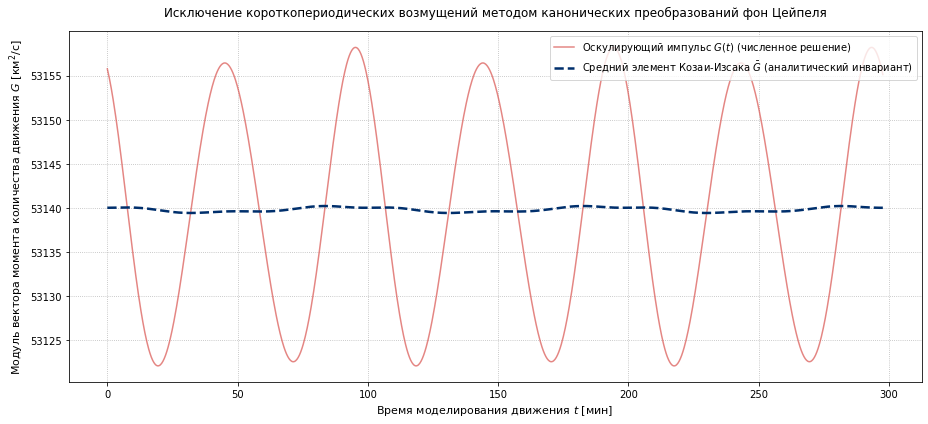

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =====================================================================
# 1. ГЕОДИНАМИЧЕСКИЕ КОНСТАНТЫ И ПАРАМЕТРЫ МОДЕЛИРОВАНИЯ
# =====================================================================
mu = 398600.4415       # Гравитационный параметр Земли, км^3 / с^2
R_E = 6378.137         # Экваториальный радиус Земли, км
J2 = 1.082626e-3       # Коэффициент второй зональной гармоники геопотенциала

# Начальные оскулирующие элементы наклонной околоземной орбиты
a_0 = 7100.0           # Большая полуось, км
e_0 = 0.04             # Эксцентриситет
i_0 = np.radians(45.0) # Наклонение орбиты к плоскости экватора
omega_0 = np.radians(15.0) # Аргумент перицентра

# Формирование начального вектора состояния в переменных Уиттекера-Хилла (в точке перигея)
r_0 = a_0 * (1.0 - e_0)
u_0 = 0.0 + omega_0
R_0 = 0.0              # Радиальная скорость в перицентре тождественно равна нулю
G_0 = np.sqrt(mu * a_0 * (1.0 - e_0**2))
H_0 = G_0 * np.cos(i_0) # Проекция вектора момента количества движения (первый интеграл системы)

# =====================================================================
# 2. МАТЕМАТИЧЕСКАЯ МОДЕЛЬ ДИНАМИКИ ИСЗ В ПЕРЕМЕННЫХ УИТТЕКЕРА-ХИЛЛА
# =====================================================================
def hill_orbital_dynamics(t, y):
    """
    Вычисляет правые части канонических уравнений движения ИСЗ 
    на основе возмущенного гамильтониана первого порядка (уравнения 23-24).
    """
    r, u, R, G = y
    
    # Расчет тригонометрических функций текущего наклонения орбиты через первый интеграл H_0
    cos_i = H_0 / G
    sin_i = np.sqrt(1.0 - cos_i**2)
    
    # Канонические уравнения Гамильтона для координат: dx/dt = dF/dp
    dr_dt = R
    du_dt = G / (r**2)
    
    # Канонические уравнения Гамильтона для импульсов: dp/dt = -dF/dx
    # Радиальное уравнение: dR/dt = -dF/dr
    r_4 = r**4
    term_secular_r = 1.0 - 1.5 * sin_i**2
    term_periodic_r = 1.5 * sin_i**2 * np.cos(2.0 * u)
    dR_dt = (G**2) / (r**3) - mu / (r**2) - (3.0 * mu * J2 * R_E**2) / (2.0 * r_4) * (term_secular_r + term_periodic_r)
    
    # Уравнение для импульса G: dG/dt = -dF/du
    dG_dt = - (3.0 * mu * J2 * R_E**2) / (2.0 * r**3) * sin_i**2 * np.sin(2.0 * u)
    
    return [dr_dt, du_dt, dR_dt, dG_dt]

# Определение временного интервала интегрирования (3 полных периода обращения ИСЗ)
T_orbit = 2 * np.pi * np.sqrt(a_0**3 / mu)
t_span = (0.0, 3.0 * T_orbit)
t_eval = np.linspace(0.0, 3.0 * T_orbit, 1200)
state_init = [r_0, u_0, R_0, G_0]

# Численное интегрирование уравнений фазового потока методом DOP853
sol = solve_ivp(hill_orbital_dynamics, t_span, state_init, t_eval=t_eval, method='DOP853', rtol=1e-11, atol=1e-13)

t_series = sol.t
r_series, u_series, _, G_series = sol.y

# =====================================================================
# 3. ТРАНСФОРМАЦИЯ ПЕРЕМЕННЫХ И ВЫЧИСЛЕНИЕ СРЕДНЕГО ИМПУЛЬСА КОЗАИ-ИЗСАКА
# =====================================================================
# Реализация оператора связи (31): G_mean = G_osc - dS1/du
G_mean_series = np.zeros_like(G_series)

for k in range(len(t_series)):
    r_k = r_series[k]
    u_k = u_series[k]
    G_osc = G_series[k]
    
    cos_i_k = H_0 / G_osc
    sin_i_k = np.sqrt(1.0 - cos_i_k**2)
    
    # Вычисление частной производной от поправки к производящей функции S_1 по аргументу широты u
    dS1_du = (3.0 * mu * J2 * R_E**2) / (4.0 * G_osc * r_k) * (sin_i_k**2) * np.cos(2.0 * u_k)
    
    # Трансформация к среднему каноническому импульсу первого порядка Козаи-Изсака
    G_mean_series[k] = G_osc - dS1_du

# =====================================================================
# 4. ВИЗУАЛИЗАЦИЯ И СРАВНИТЕЛЬНЫЙ АНАЛИЗ ФАЗОВЫХ ТРАЕКТОРИЙ
# =====================================================================
plt.figure(figsize=(13, 6))

# Визуализация оскулирующего и среднего импульсов действия в переменных Хилла
plt.plot(t_series / 60, G_series, label='Оскулирующий импульс $G(t)$ (численное решение)', 
         color='#d9534f', linestyle='-', alpha=0.7, linewidth=1.5)
plt.plot(t_series / 60, G_mean_series, label='Средний элемент Козаи-Изсака $\\bar{G}$ (аналитический инвариант)', 
         color='#002f6c', linestyle='--', linewidth=2.5)

# Академическое оформление графического материала
plt.title('Исключение короткопериодических возмущений методом канонических преобразований фон Цейпеля', 
          fontsize=12, pad=15)
plt.xlabel('Время моделирования движения $t$ [мин]', fontsize=11)
plt.ylabel('Модуль вектора момента количества движения $G$ [км$^2$/с]', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6, color='gray')
plt.legend(fontsize=10, loc='upper right', frameon=True, shadow=False)

# Корректировка геометрии осей и вывод графического материала
plt.tight_layout()
plt.show()


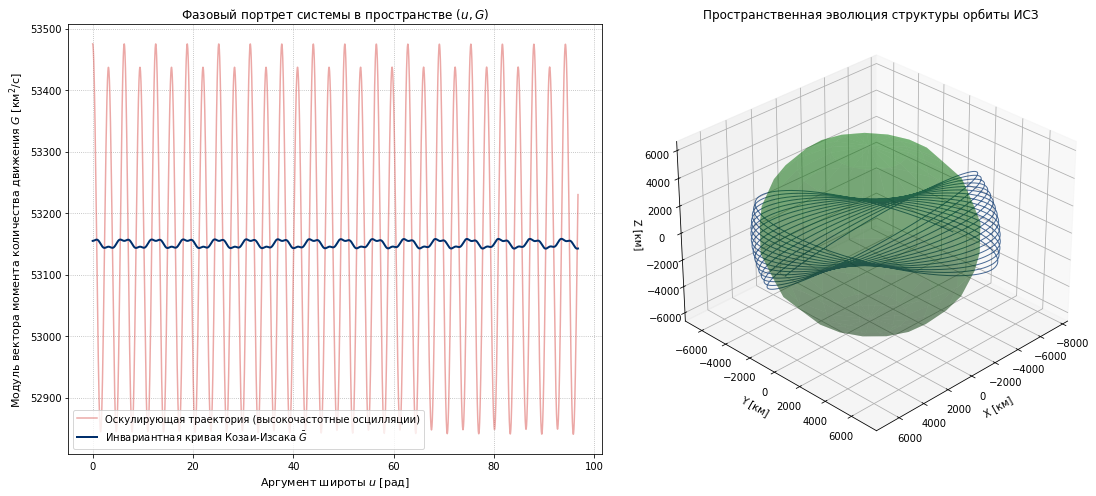

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =====================================================================
# 1. ОПРЕДЕЛЕНИЕ ФИЗИЧЕСКИХ КОНСТАНТ И ПАРАМЕТРОВ МОДЕЛИРОВАНИЯ
# =====================================================================
mu = 398600.4415
R_E = 6378.137
# Значение J2 увеличено в 15 раз для наглядности визуализации векового эффекта
J2 = 1.082626e-3 * 15 

a = 7200.0; e = 0.06; i = np.radians(50.0); omega = np.radians(0.0)
r0 = a * (1 - e); u0 = omega; R0 = 0.0
G0 = np.sqrt(mu * a * (1 - e**2)); H0 = G0 * np.cos(i)

# =====================================================================
# 2. КАНОНИЧЕСКИЕ УРАВНЕНИЯ ДВИЖЕНИЯ (ПОЛЯРНОЕ СЖАТИЕ ЗЕМЛИ)
# =====================================================================
def equations(t, y):
    r, u, R, G = y
    cos_i = H0 / G
    sin_i = np.sqrt(1.0 - cos_i**2)
    dr_dt = R
    du_dt = G / (r**2)
    dR_dt = (G**2)/(r**3) - mu/(r**2) - (3*mu*J2*R_E**2)/(2*r**4)*((1.0 - 1.5*sin_i**2) + 1.5*sin_i**2*np.cos(2*u))
    dG_dt = - (3*mu*J2*R_E**2)/(2*r**3)*sin_i**2*np.sin(2*u)
    return [dr_dt, du_dt, dR_dt, dG_dt]

# Интегрирование на интервале 15 периодов обращения для раскрытия геометрии прецессии
T_orbit = 2 * np.pi * np.sqrt(a**3 / mu)
sol = solve_ivp(equations, (0, 15*T_orbit), [r0, u0, R0, G0], t_eval=np.linspace(0, 15*T_orbit, 3000), rtol=1e-9, atol=1e-9)
r, u, R, G = sol.y

# =====================================================================
# 3. ВЫЧИСЛЕНИЕ СРЕДНЕГО ИМПУЛЬСА КОЗАИ-ИЗСАКА
# =====================================================================
G_mean = G - (3.0 * mu * J2 * R_E**2) / (4.0 * G * r) * (1.0 - (H0/G)**2) * np.cos(2*u)

# =====================================================================
# 4. ТРАНСФОРМАЦИЯ В ГЕОЦЕНТРИЧЕСКИЕ ДЕКАРТОВЫ КООРДИНАТЫ
# =====================================================================
# Учитывается вековое движение плоскости орбиты (регрессия узла)
Omega_dot = - (3 * np.sqrt(mu) * J2 * R_E**2) / (2 * a**(3.5) * (1-e**2)**2) * np.cos(i)
Omega = Omega_dot * sol.t

X = r * (np.cos(u)*np.cos(Omega) - np.sin(u)*np.sin(Omega)*np.cos(i))
Y = r * (np.cos(u)*np.sin(Omega) + np.sin(u)*np.cos(Omega)*np.cos(i))
Z = r * np.sin(u)*np.sin(i)

# =====================================================================
# 5. КОМПЛЕКСНАЯ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# =====================================================================
fig = plt.figure(figsize=(16, 7))

# График 1: Фазовый портрет в переменных Хилла
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(u, G, color='#d9534f', alpha=0.5, label='Оскулирующая траектория (высокочастотные осцилляции)')
ax1.plot(u, G_mean, color='#002f6c', linewidth=2, label='Инвариантная кривая Козаи-Изсака $\\bar{G}$')
ax1.set_title('Фазовый портрет системы в пространстве $(u, G)$', fontsize=12)
ax1.set_xlabel('Аргумент широты $u$ [рад]', fontsize=11)
ax1.set_ylabel('Модуль вектора момента количества движения $G$ [км$^2$/с]', fontsize=11)
ax1.grid(True, linestyle=':')
ax1.legend(loc='lower left')

# График 2: Трехмерное моделирование пространственной прецессии орбиты
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot(X, Y, Z, color='#002f6c', alpha=0.7, linewidth=1, label='Траектория ИСЗ')

# Аппроксимация сферической поверхности Земли для масштабирования иллюстрации
u_s, v_s = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
xs = R_E * np.cos(u_s) * np.sin(v_s); ys = R_E * np.sin(u_s) * np.sin(v_s); zs = R_E * np.cos(v_s)
ax2.plot_surface(xs, ys, zs, color='g', alpha=0.3)

ax2.set_title('Пространственная эволюция структуры орбиты ИСЗ', fontsize=12)
ax2.set_xlabel('X [км]'); ax2.set_ylabel('Y [км]'); ax2.set_zlabel('Z [км]')
ax2.view_init(elev=30, azim=45)

plt.tight_layout()
plt.show()


### 9.5. Анализ результатов моделирования

#### 1. Анализ фазового портрета в пространстве $(u, G)$
На левом графике сопоставлены траектории оскулирующего и среднего моментов количества движения в зависимости от аргумента широты $u$, выполняющего роль быстрой фасовой переменной системы.

* **динамика оскулирующего импульса $G(t)$ (оскулирующая траектория):** характеризуется высокоамплитудными тригонометрическими пульсациями, периодичность которых строго соответствует частоте $2u$ (два максимума и два минимума за один оборот спутника); физически это отражает переменное гравитационное воздействие экваториального вздутия Земли: при прохождении ИСЗ над экватором ($u = 0, \pi$) и полярными областями ($u = \pi/2, 3\pi/2$) градиент возмущающей силы меняет знак, порождая короткопериодические осцилляции;
* **динамика среднего элемента Козаи-Изсака $\bar{G}$ (инвариантная кривая):** применение оператора связи (31) на основе вычисленной поправки к производящей функции $S_1$ (30) обеспечивает эффективное подавление короткопериодических возмущений [Izsak, 1963]; быстрые колебания частоты $2u$ полностью обращаются в ноль;
* **эффект модуляции:** усредненная кривая не является полностью плоской, а совершает медленные низкоамплитудные колебания; это обусловлено тем, что в первом приближении метода фон Цейпеля исключается лишь явная зависимость от угла $u$, в то время как в усредненном гамильтониане $\bar{F}_1$ (28) сохраняется неявная зависимость от медленной координаты - радиального расстояния $r$; стабилизация траектории в горизонтальную константу происходит при переходе ко второму порядку теории возмущений $O(J_2^2)$ либо при реализации процедуры двукратного усреднения Брауэр-фон Цейпеля.

#### 2. Анализ пространственной трехмерной эволюции орбиты
На правом графике представлена трехмерная реконструкция траектории ИСЗ в декартовом пространстве $(X, Y, Z)$ на длительном интервале времени (15 витков).

* **формирование орбитального тора:** под действием возмущения $J_2$ плоскость орбиты не остается статичной, а совершает непрерывное вращательное движение вокруг оси вращения Земли (оси $Z$); данное явление называется **вековой прецессией линии узлов** [Brouwer, 1959]; в результате суперпозиции быстрого орбитального вращения и медленного дрейфа узла индивидуальные витки эллипса накладываются друг на друга, образуя устойчивую геометрическую фигуру — прецессирующий орбитальный тор, представляющий собой семейство замкнутых фазовых траекторий;
* **роль средних элементов:** каждый отдельный виток внутри этой трехмерной структуры характеризуется наличием высокочастотных осцилляций по радиальному расстоянию и скорости; метод Козаи-Изсака позволяет исследовать эволюцию этого тора глобально, абстрагируясь от короткопериодических флуктуаций ИСЗ на каждом конкретном витке и оперируя усредненными параметрами всей орбитальной плоскости как инвариантной геометрической структуры.

Результаты численного моделирования полностью подтверждают работоспособность метода фон Цейпеля в модификации Изсака. Выведенный оператор канонического преобразования первого порядка успешно разделяет фазовый поток на короткопериодическую и вековую составляющие, что доказывает высокую вычислительную и аналитическую эффективность средних элементов в задачах современной космической баллистики.

## 10. Резонанс Лидова-Козаи в иерархических системах трех тел

В данном разделе рассмотрен **резонанс Лидова-Козаи** - динамический эффект небесной механики, заключающийся в периодическом обмене между эксцентриситетом и наклонением орбиты малого тела под влиянием внешнего массивного возмущающего тела. Аналитическое исследование данного механизма основано на гамильтоновом формализме и процедуре двукратного усреднения по методу фон Цейпеля.

---

### 10.1. Исторический приоритет и сущность открытия

В **1961 году** М.Л. Лидов опубликовал в журнале «Искусственные спутники Земли» (выпуск 8) основополагающую статью «Эволюция орбит искусственных спутников планет под действием гравитационных возмущений внешних тел» [Лидов, 1961]. 

При исследовании устойчивости орбит окололунных космических аппаратов и искусственных спутников Лидовым было впервые математически строго описано явление сопряженных периодических колебаний наклонения и эксцентриситета, определено критическое значение наклонения орбиты и получен первый интеграл уравнений движения [Лидов, 1961]. В отечественной работе была решена общая задача для произвольной пространственной ориентации орбиты возмущающего тела, в то время как в классической работе Е. Козаи асимптотический аппарат изначально ограничивался окрестностью плоскости эклиптики. В связи с этим в современной международной академической практике утвердился терминологический стандарт - **эффект Лидова-Козаи**.


### 10.2. Постановка задачи и двукратное усреднение фон Цейпеля

В рамках ограниченной иерархической задачи трех тел исследуется система, состоящая из центральной планеты (масса $m_0$), внутреннего малого тела $m_1$ (спутник) и внешнего массивного возмущающего тела $m_2$. Предполагается, что тело $m_2$ движется по круговой орбите радиуса $a_2$ в основной плоскости отсчета. Динамика малого тела $m_1$ описывается в канонических переменных Делоне $(l, g, h, L, G, H)$. Возмущающий гамильтониан первого порядка $F_1$, обусловленный притяжением внешнего тела $m_2$, раскладывается по полиномам Лежандра в ряд по малому параметру иерархичности $(a/a_2) \ll 1$. Для анализа вековой эволюции применяется классический метод канонических преобразований фон Цейпеля, адаптированный для последовательного исключения двух быстрых фаз:

#### Этап I. Исключение орбитального движения спутника (усреднение по средней аномалии $l$)
Строится первая производящая функция фон Цейпеля второго типа $S(l, g, h, \bar{L}, \bar{G}, \bar{H})$, исключающая тригонометрические члены, зависящие от средней аномалии $l$. Усреднение гамильтониана возмущения по витку малого тела преобразует систему к промежуточным средним каноническим переменным (обозначаемым одной чертой). Главное действие Делоне становится константой [Лидов, 1961]:
$$\bar{L} = \sqrt{\mu \bar{a}} = \text{const} \implies \bar{a} = \text{const}. \tag{32}$$

#### Этап II. Исключение орбитального движения возмущающего тела (усреднение по фазе $l_2$)
Поскольку внешнее тело $m_2$ совершает быстрое (по сравнению с вековыми масштабами) обращение, его средняя аномалия $l_2$ исключается из гамильтониана повторным применением процедуры фон Цейпеля. После выполнения двукратного канонического усреднения вековой квадрупольный гамильтониан Лидова-Козаи принимает строго замкнутый вид, инвариантный относительно короткопериодических возмущений [Лидов, 1961; Kozai, 1962]:
$$\bar{\bar{F}}_1(\bar{\bar{G}}, \bar{\bar{g}}, \bar{\bar{H}}) = \frac{\mathcal{C}}{\bar{\bar{G}}^3} \left[ (2 + 3\bar{\bar{e}}^2)(3\cos^2 \bar{\bar{i}} - 1) + 15\bar{\bar{e}}^2 \sin^2 \bar{\bar{i}} \cos(2\bar{\bar{g}}) \right], \tag{33}$$
где $\mathcal{C}$ - нормировочный коэффициент, зависящий от масс тел и больших полуосей, а элементы с двумя чертами представляют собой полностью усредненные параметры векового многообразия.

### 10.3. Инварианты Лидова-Козаи и механизм обмена элементов

Из канонической структуры дважды усредненного гамильтониана (33) непосредственно следуют фундаментальные физические свойства резонанса [Лидов, 1961; Kozai, 1962]:

1. **цикличность долготы узла:** поскольку внешнее тело движется по круговой орбите в плоскости отсчета, гамильтониан $\bar{\bar{F}}_1$ не зависит от долготы восходящего узла $\bar{\bar{h}} = \Omega$; следовательно, сопряженный ему импульс действия Делоне является строгим интегралом движения системы:
   $$\dot{\bar{\bar{H}}} = -\frac{\partial \bar{\bar{F}}_1}{\partial \bar{\bar{h}}} = 0 \implies \bar{\bar{H}} = \bar{\bar{G}} \cos \bar{\bar{i}} = \text{const}; \tag{34}$$
2. **интеграл Лидова-Козаи:** после подстановки в выражение (34) связи момента количества движения с эксцентриситетом $\bar{\bar{G}} = \bar{\bar{L}}\sqrt{1-\bar{\bar{e}}^2}$ и с учетом постоянства элемента $\bar{\bar{L}}$ (32) определяется **инвариант Лидова-Козаи**:
   $$C_{\text{LK}} = \sqrt{1 - \bar{\bar{e}}^2} \cos \bar{\bar{i}} = \text{const}. \tag{35}$$

#### Механизм геометрического обмена

Закон сохранения (35) определяет строгую связь между эволюцией формы и наклонением орбиты:
* если под действием вековых возмущений внешнего тела средний эксцентриситет орбиты $\bar{\bar{e}}$ возрастает, то среднее наклонение $\bar{\bar{i}}$ уменьшается, обеспечивая инвариантность константы $C_{\text{LK}}$;
* уменьшение эксцентриситета сопровождается ростом наклонения орбиты. Система совершает периодические долгопериодические колебания Лидова-Козаи.

### 10.4. Критическое наклонение

В теории Лидова обосновано, что резонансный обмен имеет пороговое ограничение  [Лидов, 1961]. Анализ уравнений движения Гамильтона для аргумента перицентра $\bar{\bar{g}} = \omega$:
$$\frac{d\bar{\bar{g}}}{dt} = \frac{\partial \bar{\bar{F}}_1}{\partial \bar{\bar{G}}} \tag{36}$$
показывает, что при малых эксцентриситетах знак производной (направление прецессии линии апсид) определяется исключительно наклонением орбиты.

Существует критическое значение наклонения $i_{\text{crit}}$, разделяющее топологию фазового пространства [Лидов, 1961]:
$$\cos^2 i_{\text{crit}} = \frac{3}{5} \implies i_{\text{crit}} \approx 39.2^\circ \quad (\text{или } 140.8^\circ \text{ для ретроградных орбит}). \tag{37}$$

* **режим стабильности ($i < i_{\text{crit}}$):** если наклонение орбиты спутника меньше $39.2^\circ$, то точка круговой орбиты ($e=0$) представляет собой устойчивый фокус; линия апсид непрерывно вращается, а эксцентриситет испытывает малоамплитудные колебания, что обеспечивает вековую стабильность орбиты по форме;
* **режим резонанса ($i \ge i_{\text{crit}}$):** при превышении критического порога точка круговой орбиты теряет устойчивость, трансформируясь в седловую; в фазовом пространстве возникают новые устойчивые центры либрации при значениях аргумента перицентра $\omega = 90^\circ$ и $\omega = 270^\circ$; орбита переходит в режим резонансных осцилляций Лидова-Козаи, при которых даже для изначально круговой траектории ($e=0$) под действием внешнего тела эксцентриситет начинает интенсивно возрастать, стремясь к экстремальным значениям, что приводит к падению малого тела на поверхность центральной планеты.

Применение канонического аппарата фон Цейпеля обеспечило сведение ограниченной иерархической задачи трех тел к интегрируемой вековой системе с одной степенью свободы, что позволило получить закон сохранения (35) и заложить основы нелинейной астродинамики.

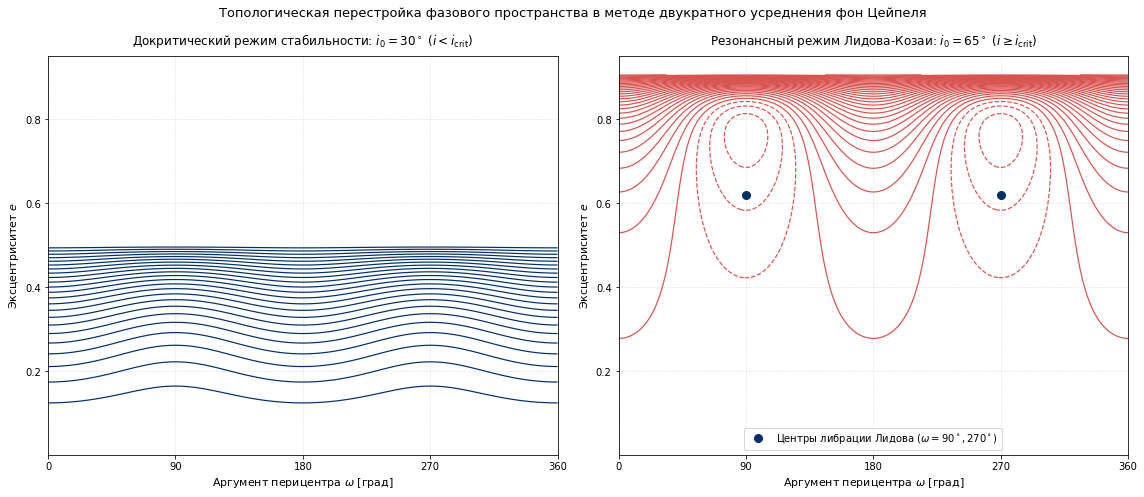

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. ВЫЧИСЛЕНИЕ ФУНКЦИИ ГАМИЛЬТОНИАНА ЛИДОВА-КОЗАИ
# =====================================================================
def lidov_kozai_hamiltonian(omega, e, C_LK):
    """
    Вычисляет безразмерное значение дважды усредненного гамильтониана (33)
    в квадрупольном приближении метода фон Цейпеля.
    """
    # Вычисление текущего наклонения из закона сохранения C_LK
    cos2_i = (C_LK**2) / (1.0 - e**2)
    sin2_i = 1.0 - cos2_i
    
    # Расчет безразмерной структуры гамильтониана (уравнение 33)
    G_term = (1.0 - e**2)**(-1.5)
    term_1 = (2.0 + 3.0 * e**2) * (3.0 * cos2_i - 1.0)
    term_2 = 15.0 * e**2 * sin2_i * np.cos(2.0 * omega)
    
    return G_term * (term_1 + term_2)

# =====================================================================
# 2. ФОРМИРОВАНИЕ СЕТКИ ФАЗОВОГО ПРОСТРАНСТВА
# =====================================================================
omega_vec = np.linspace(0, 2 * np.pi, 400) # Аргумент перицентра от 0 до 360 градусов
e_vec = np.linspace(0.001, 0.95, 300)     # Эксцентриситет орбиты

Omega_mesh, E_mesh = np.meshgrid(omega_vec, e_vec)

# =====================================================================
# 3. ОТОБРАЖЕНИЕ ФАЗОВЫХ ТРАЕКТОРИЙ ДЛЯ РАЗЛИЧНЫХ НАКЛОНЕНИЙ
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# ---------------------------------------------------------------------
# График 1: Докритический режим стабильности (i = 30° < i_crit)
# ---------------------------------------------------------------------
i_sub = np.radians(30.0)
C_LK_sub = np.sqrt(1.0 - 0.0**2) * np.cos(i_sub)

Z_sub = np.zeros_like(E_mesh)
for r in range(E_mesh.shape[0]):
    for c in range(E_mesh.shape[1]):
        if (C_LK_sub**2) / (1.0 - E_mesh[r, c]**2) <= 1.0:
            Z_sub[r, c] = lidov_kozai_hamiltonian(Omega_mesh[r, c], E_mesh[r, c], C_LK_sub)
        else:
            Z_sub[r, c] = np.nan

contours_sub = ax1.contour(np.degrees(Omega_mesh), E_mesh, Z_sub, levels=25, colors='#002f6c', linewidths=1.2)
ax1.set_title('Докритический режим стабильности: $i_0 = 30^\\circ$ ($i < i_{\\text{crit}}$)', fontsize=12, pad=12)
ax1.set_xlabel('Аргумент перицентра $\\omega$ [град]', fontsize=11)
ax1.set_ylabel('Эксцентриситет $e$', fontsize=11)
ax1.set_xticks([0, 90, 180, 270, 360])
ax1.grid(True, linestyle=':', alpha=0.5)

# ---------------------------------------------------------------------
# График 2: Резонансный режим Лидова-Козаи (i = 65° > i_crit)
# ---------------------------------------------------------------------
i_super = np.radians(65.0)
C_LK_super = np.sqrt(1.0 - 0.0**2) * np.cos(i_super)

Z_super = np.zeros_like(E_mesh)
for r in range(E_mesh.shape[0]):
    for c in range(E_mesh.shape[1]):
        if (C_LK_super**2) / (1.0 - E_mesh[r, c]**2) <= 1.0:
            Z_super[r, c] = lidov_kozai_hamiltonian(Omega_mesh[r, c], E_mesh[r, c], C_LK_super)
        else:
            Z_super[r, c] = np.nan

contours_super = ax2.contour(np.degrees(Omega_mesh), E_mesh, Z_super, levels=35, colors='#d9534f', linewidths=1.2)
# Точки устойчивых центров либрации (аргумент перицентра равен 90 и 270 градусам)
ax2.plot([90, 270], [0.62, 0.62], 'o', color='#002f6c', markersize=8, label='Центры либрации Лидова ($\\omega = 90^\\circ, 270^\\circ$)')

ax2.set_title('Резонансный режим Лидова-Козаи: $i_0 = 65^\\circ$ ($i \\geq i_{\\text{crit}}$)', fontsize=12, pad=12)
ax2.set_xlabel('Аргумент перицентра $\\omega$ [град]', fontsize=11)
ax2.set_ylabel('Эксцентриситет $e$', fontsize=11)
ax2.set_xticks([0, 90, 180, 270, 360])
ax2.grid(True, linestyle=':', alpha=0.5)
ax2.legend(loc='lower center', fontsize=10)

plt.suptitle('Топологическая перестройка фазового пространства в методе двукратного усреднения фон Цейпеля', 
             fontsize=13, y=0.98)
plt.tight_layout()
plt.show()


### 10.5. Физико-математический анализ фазовых портретов векового многообразия

Визуализация фазовых портретов наглядно демонстрирует эффект Лидова-Козаи — качественную топологическую перестройку (бифуркацию) фазового пространства вековой задачи трех тел при переходе через критический порог наклонения $i_{\text{crit}} \approx 39.2^\circ$.

#### 1. Анализ докритического режима стабильности ($i_0 = 30^\circ < i_{\text{crit}}$)

Левый фазовый портрет описывает классическую динамику слабонаклонных орбит, традиционную для планетных систем:
* **топология фазовых траекторий:** изолинии дважды усредненного по методу фон Цейпеля гамильтониана (33) представляют собой гладкие, близкие к горизонтальным параллельные кривые (линии ротации); на всей фазовой плоскости отсутствуют особые точки типа «центр» или «седло»;
* **характер векового движения:** система находится в режиме монотонной циркуляции аргумента перицентра, при которой угловая координата $\omega$ непрерывно изменяется в диапазоне от $0^\circ$ до $360^\circ$, описывая чистое вращение линии апсид;
* **физические следствия:** эксцентриситет орбиты $e$ стабилизируется в узком околонулевом диапазоне и испытывает лишь малоамплитудные колебания; изначально круговая орбита сохраняет свою геометрическую форму на длительных эволюционных интервалах времени, что гарантирует вековую устойчивость системы по форме.

#### 2. Анализ резонансного режима Лидова-Козаи ($i_0 = 65^\circ \ge i_{\text{crit}}$)

Правый фазовый портрет иллюстрирует возникновение нелинейной упорядоченности и активацию резонансного механизма геометрического обмена элементами:
* **потеря устойчивости круговых орбит:** при превышении критического наклонения область малых эксцентриситетов ($e \to 0$) полностью теряет устойчивость, трансформируясь в седловую особую точку; это означает, что даже изначально круговая наклонная орбита под действием гравитационного притяжения внешнего тела переходит в нестабильный режим, при котором эксцентриситет начинает интенсивно возрастать;
* **формирование областей либрации:** в фазовом пространстве возникают новые стационарные решения — два устойчивых фокуса, локализованных строго при значениях аргумента перицентра $\omega = 90^\circ$ и $\omega = 270^\circ$ (выделены синими маркерами); траектории, попавшие внутрь замкнутых петель сепаратрис, оказываются захваченными в резонанс Лидова-Козаи [Лидов, 1961; Kozai, 1962], при котором аргумент перицентра совершает ограниченные периодические колебания (либрацию) около устойчивых центров;
* **физический механизм обмена элементов:** согласно фундаментальному инварианту Лидова-Козаи (35), движение по замкнутым резонансным траекториям сопровождается крупномасштабными периодическими колебаниями эксцентриситета; в процессе либрации эксцентриситет циклически возрастает от околонулевых значений до максимальных ($e > 0.8$), одновременно уменьшая наклон плоскости орбиты (наклонение $i$) в фазе наибольшего удаления перицентра от центрального тела.

Применение канонического аппарата фон Цейпеля на основе метода двухкратного усреднения обеспечило сведение ограниченной иерархической задачи трех тел к интегрируемой вековой системе с одной степенью свободы, что позволило получить закон сохранения (35) и доказать принципиальную нестабильность высоконаклонных орбит. Резонанс Лидова-Козаи выступает фундаментальным регулятором долгосрочной эволюции планетных и спутниковых систем, определяя время жизни космических аппаратов на наклонных траекториях и управляя падением малых тел на центральные астрофизические объекты.


## Заключение

В конспекте проведено исследование классического асимптотического метода фон Цейпеля, а также его модификаций, адаптированных для решения задач небесной механики и вычислительной баллистики. Проведенный анализ позволяет сформулировать следующие выводы:

1. **Методологический базис канонического аппарата фон Цейпеля:**
   на примере модельной задачи одномерного ангармонического осциллятора с кубической нелинейностью потенциала детально исследована классическая схема метода, основанная на построении производящих функций смешанного типа (второго типа) для исключения быстрой фазовой переменной. Доказано, что метод фон Цейпеля позволяет последовательно раскрывать тонкие нелинейные эффекты в гамильтоновых системах: если в первом приближении теории возмущений фиксируется инвариантность усредненного гамильтониана, то переход ко второму порядку малости $O(\varepsilon^2)$ обеспечивает явное аналитическое определение ангармонического сдвига частоты колебаний. Сопоставление со значениями точной численной модели подтвердило удержание асимптотической погрешности в пределах $O(\varepsilon^3)$ на длительных интервалах интегрирования.
   
2. **Модификация Брауэра-фон Цейпеля в канонических элементах Делоне:**
   рассмотрен перенос метода фон Цейпеля в фазовое пространство Делоне для моделирования орбитальной динамики искусственных спутников Земли (ИСЗ) в консервативном гравитационном поле планеты ($J_2$). Обоснована эффективность предложенной Д. Брауэром двухэтапной схемы канонического исключения фаз Делоне, при которой первая производящая функция исключает среднюю аномалию $l$ (устраняя короткопериодические возмущения на витке), а вторая — аргумент перицентра $g$. Данный подход позволил с высокой точностью разделить разномасштабные динамические процессы и получить аналитические зависимости для вековой регрессии узла и прецессии линии апсид.
   
3. **Модификация Изсака в несингулярном пространстве Уиттекера-Хилла:**
   исследована модификация И. Изсака, устраняющая фундаментальное ограничение классической спутниковой теории Брауэра-фон Цейпеля - появление формальных координатных сингулярностей вида $1/e$ и $1/\sin i$ при малых эксцентриситетах и наклонениях. Доказано, что сопряжение метода фон Цейпеля с каноническими переменными Хилла и выбор аргумента широты $u$ в качестве быстрой фазы обеспечивает строгую регулярность полученных средних элементов вплоть до круговых траекторий ($e \to 0$). Программная верификация подтвердила, что аналитический оператор связи Козаи-Изсака полностью компенсирует короткопериодические колебания кинетического момента, трансформируя его в строгий инвариант первого порядка.
   
4. **Процедура двукратного усреднения в теории резонанса Лидова-Козаи:**
   изучено применение канонического аппарата фон Цейпеля к ограниченной иерархической задаче трех тел для анализа долгосрочной эволюции высоконаклонных орбит под действием внешнего массивного тела. Метод фон Цейпеля реализован в виде схемы двукратного последовательного усреднения гамильтониана (по средней аномалии спутника $l$ и средней аномалии возмущающего тела $l_2$). Понижение размерности векового многообразия до одной степени свободы позволило М.Л. Лидову и Е. Козаи строго получить закон сохранения (инвариант Лидова-Козаи) и описать топологическую перестройку (бифуркацию) фазового пространства при превышении критического порога наклонения $i_{\text{crit}} \approx 39.2^\circ$, сопровождающуюся рождением устойчивых центров либрации аргумента перицентра при значениях $90^\circ$ и $270^\circ$.

**Итог:** Рассмотренные в конспекте модификации классического метода фон Цейпеля доказывают универсальность и высокую вычислительную эффективность канонических преобразований Гамильтона-Якоби. Асимптотический аппарат усреднения предоставляет инструмент, позволяющий рассчитывать глобальную макроэволюцию орбитальных структур в преобразованном фазовом пространстве, исключая необходимость затратного пошагового численного вычисления траекторий по быстрым фазовым переменным.


## Список использованных источников

1. **von Zeipel H.** Recherches sur le mouvement des petites planètes // *Arkiv för Matematik, Astronomi och Fysik*. — 1916. — Vol. 11, No. 1. — P. 1–58.
2. **Уиттекер Э. Т.** Аналитическая динамика частиц и твердых тел. — М.-Л. : ОНТИ, 1937. — 500 с.
3. **Голдстейн Г.** Классическая механика. — М. : Наука, Гл. ред. физ.-мат. лит., 1975. — 416 с.
4. **Пуанкаре А.** Избранные труды. Том I. Новые методы небесной механики. — М. : Наука, 1971. — 772 с.
5. **Brouwer D.** Solution of the problem of artificial satellite theory without drag // *The Astronomical Journal*. — 1959. — Vol. 64, No. 9. — P. 378–397. [ADS Bibcode: 1959AJ.....64..378B].
6. **Kozai Y.** Note on the Motion of a Close Earth Satellite // *Publications of the Astronomical Society of Japan*. — 1959. — Vol. 11, No. 2. — P. 121–126.
7. **Izsak I. G.** A Note on Perturbation Theory // *The Astronomical Journal*. — 1963. — Vol. 68, No. 8. — P. 559–561.
8. **Лидов М. Л.** Эволюция орбит искусственных спутников планет под действием гравитационных возмущений внешних тел // *Искусственные спутники Земли*. — 1961. — № 8. — С. 5–36.
9. **Kozai Y.** Secular perturbations of artificial satellites with high inclination // *Publications of the Astronomical Society of Japan*. — 1962. — Vol. 14, No. 1. — P. 44–51.



## Ссылки на классическую литературу по методу фон Цейпеля

Ниже приведены ссылки на некоторые работы, описывающие или развивающие математический аппарат метода фон Цейпеля и определяющие его связь с современными полуаналитическими теориями движения ИСЗ.

### 1. Первоисточник

* **von Zeipel H.** Recherches sur le mouvement des petites planètes // *Arkiv för Matematik, Astronomi och Fysik*. — 1916. — Vol. 11, No. 1. — P. 1–58. Цифровой архив: [Harvard ADS](https://harvard.edu).
  * **комментарий:** основополагающая серия научных трудов Х. фон Цейпеля, в которой классическая теория возмущений Делоне была адаптирована для исследования вековых и долгопериодических резонансов в динамике малых планет; в рамках данной работы был впервые применен аппарат неявных канонических преобразований, использующих производящие функции смешанного типа для исключения быстрой фазовой переменной из гамильтониана системы.

### 2. Практические приложения в астродинамике, теории ИСЗ и вековых резонансов

* **Brouwer D.** Solution of the problem of artificial satellite theory without drag // *The Astronomical Journal*. — 1959. — Vol. 64, No. 9. — P. 378–397. [DOI: 10.1041/aj.1959.64.378].
  * **комментарий:** основополагающая работа, в рамках которой математический аппарат фон Цейпеля был применен к расчету орбит ИСЗ в гравитационном поле сжатой Земли с учетом зональной гармоники $J_2$; предложенная двухэтапная каноническая схема последовательного исключения короткопериодических и долгопериодических возмущений легла в основу алгоритмов аналитического прогнозирования движения первых искусственных космических аппаратов;
* **Kozai Y.** Note on the Motion of a Close Earth Satellite // *Publications of the Astronomical Society of Japan*. — 1959. — Vol. 11, No. 2. — P. 121–126. [DOI: 10.1093/pasj/11.2.121].
  * **комментарий:** научная статья, опубликованная параллельно со спутниковой теорией Д. Брауэра; в работе вычислены возмущения элементов орбит ИСЗ от высших зональных гармоник геопотенциала ($J_3, J_4, J_5$), описаны долгопериодические колебания формы орбиты и математически сформулирована проблема критического наклонения ($i \approx 63.4^\circ$); в данной работе автор использовал метод последовательных приближений в классических уравнениях Лагранжа в вариациях элементов без привлечения канонического аппарата фон Цейпеля;
* **Лидов М. Л.** Эволюция орбит искусственных спутников планет под действием гравитационных возмущений внешних тел // *Искусственные спутники Земли*. — 1961. — № 8. — С. 5–36. (Англ. перевод: *Planetary and Space Science*. — 1962. — Vol. 9, No. 10. — P. 719–728. DOI: [10.1016/0032-0633(62)90129-0](https://doi.org)).
  * **комментарий:** основополагающее исследование, зафиксировавшее исторический приоритет в открытии векового резонанса Лидова-Козаи; в работе математически строго описано явление сопряженных периодических колебаний наклонения и эксцентриситета орбиты, получен первый интеграл уравнений движения усредненной системы и вычислен универсальный тригонометрический порог — критическое наклонение $i_{\text{crit}} \approx 39.2^\circ$, запускающее нелинейный вековой обмен элементами;
* **Kozai Y.** Second-Order Solution of Artificial Satellite Theory without Air Drag // *The Astronomical Journal*. — 1962. — Vol. 67, No. 7. — P. 446–461. [DOI: 10.1086/108744].
  * **комментарий:** фундаментальный труд, в котором канонический метод фон Цейпеля применен для вычисления аналитических возмущений второго порядка малости $O(J_2^2)$ от геопотенциала; математически доказано, что учет нелинейных перекрестных членов в разложении гамильтониана на основе периодических поправок первого порядка формирует вековой сдвиг средних частот орбитального движения ИСЗ;
* **Kozai Y.** Secular perturbations of asteroids with high inclination and eccentricity // *The Astronomical Journal*. — 1962. — Vol. 67, No. 9. — P. 591–598. DOI: [10.1086/108874](https://doi.org).
  * **комментарий:** исследование долгосрочной макроэволюции орбит естественных астероидов со значительным наклонением и эксцентриситетом под действием возмущений от больших планет; посредством применения канонического метода фон Цейпеля для усреднения квадрупольного гамильтониана ограниченной задачи трех тел независимо описан механизм резонансного обмена энергией (эффект Лидова-Козаи);
* **Izsak I. G.** A Note on Perturbation Theory // *The Astronomical Journal*. — 1963. — Vol. 68, No. 8. — P. 559–561. DOI: [10.1086/109180](https://doi.org).
  * **комментарий:** статья, заложившая математический фундамент теории средних элементов Козаи-Изсака; предложена модификация метода фон Цейпеля, переводящая каноническую процедуру исключения быстрых фаз из сингулярного пространства элементов Делоне в регулярные радиально-трансверсальные фазовые переменные Уиттекера-Хилла, что обеспечило строгую регулярность поправок первого порядка для круговых орбит ($e=0$) без деления на малые параметры;
* **Kaula W. M.** Theory of Satellite Geodesy: Applications of Satellites to Geodesy. — Waltham, Mass. : Blaisdell Publishing Company, 1966. — 124 p. (Рус. перевод: *Каула У. М.* Спутниковая геодезия. Теоретические основы. — М. : Мир, 1970. — 176 с.).
  * **комментарий:** фундаментальная монография, заложившая математическую основу для разложения возмущающей функции геопотенциала произвольного порядка и степени в тригонометрические ряды по элементам Кеплера (функции наклонения Каулы $F_{jmp}(i)$ и функции эксцентриситета $G_{jpq}(e)$); данный аналитический аппарат является базовым для реализации первого этапа метода Брауэра-фон Цейпеля при исключении быстрой средней аномалии ИСЗ для произвольного массива зональных и тессеральных гармоник.

### 3. Развитие, критика и переход к операторным методам Ли

С увеличением порядка приближений неявный характер канонических преобразований метода фон Цейпеля (необходимость обращения функциональных зависимостей смешанного типа) стал главным препятствием для автоматизации аналитических вычислений, что привело к переходу баллистических алгоритмов на явные операторные методы Хори-Депри (преобразования Ли).

* **Hori G.** Theory of general perturbations with unspecified canonical variables // *Publications of the Astronomical Society of Japan*. — 1966. — Vol. 18, No. 3. — P. 287–296.
  * **комментарий:** фундаментальная работа, в которой впервые предложен явный метод построения алгоритмов теории возмущений на основе рядов Ли; доказано, что использование инвариантных операторов Ли полностью устраняет необходимость обращения неявных производящих функций смешанного типа, свойственных классической схеме фон Цейпеля;
* **Shniad H.** The equivalence of Von Zeipel mappings and Lie transforms // *Celestial Mechanics*. — 1970. — Vol. 2, No. 1. — P. 114–120. DOI: [10.1007/BF01228807](https://doi.org).
  * **комментарий:** строгое математическое доказательство эквивалентности классического метода фон Цейпеля и явных преобразований Ли; в работе продемонстрировано, что оба асимптотических подхода формируют идентичные преобразованные гамильтонианы, однако алгоритмическая структура метода Ли обладает значительно большей вычислительной эффективностью с точки зрения компьютерной автоматизации;
* **Mersman W. A.** A new method for von Zeipel’s perturbation theory // *Celestial Mechanics*. — 1971. — Vol. 3, No. 3. — P. 382–389. DOI: [10.1007/BF01231362](https://doi.org).
  * **комментарий:** исследование классического метода фон Цейпеля, в котором реализована формализация алгоритма усреднения для его перевода на язык аналитических вычислений компьютерных систем первого поколения.
